# Battery Arbitrage Analysis — DE-LU Day-Ahead Market

**Author:** Juan R. Fernandez

---

## Business Problem

A **Battery Energy Storage System (BESS)** earns revenue by buying electricity when prices are
low and selling when they are high — a strategy known as *price arbitrage*. The revenue depends
directly on the **price granularity** the battery can trade against.

In the German–Luxembourg (DE-LU) bidding zone, the EPEX day-ahead market offers two contract
types:

| Contract | Resolution | Prices per day |
|---|---|---|
| **MTU-15** (15-minute) | One price per 15-min delivery interval | 96 |
| **MTU-60** (60-minute) | One price per hourly interval | 24 |

**Decision question:** *Which contract type should a 1 MW / 2 MWh battery trade to maximise
arbitrage revenue — and by how much does the choice matter?*

Finer resolution exposes more within-hour price dispersion, creating more arbitrage
opportunities. This analysis quantifies the revenue difference using six months of real DE-LU
prices (January–June 2022) and benchmarks two dispatch strategies:

1. **Greedy backtest** — charge in the cheapest intervals, discharge in the dearest.
   Transparent, fast, and easy to audit — used as a lower-bound benchmark.
2. **LP optimisation** — an exact linear programme that finds the best physically feasible
   schedule given the battery’s power, energy, and efficiency constraints.

The reusable analysis code lives in `src/battery_analysis/` and is covered by unit tests
(`tests/`).

## Method & key assumptions

**Analytical approach** — a standard EDA-to-decision workflow: **data-quality** checks (missing
values, duplicate timestamps, gaps) → **descriptive statistics & distributions** →
**multi-resolution EDA** (resample to hour/day/week/month + rolling volatility) → **business
modelling** (arbitrage backtest + linear-program optimisation).

**Key assumptions** (stated explicitly so they can be challenged):

- **Timezone.** Prices are local **CET/CEST**; each delivery interval is indexed by its *start*
  in local wall-clock time so the intraday shape lines up with the German clock.
- **Negative prices are real** (Germany 2022) and kept.
- **Battery base case:** 1 MW / 2 MWh (2-hour) lithium BESS, 90 % round-trip efficiency,
  **10–90 % usable SoC window**, **perfect price foresight** ⇒ revenue is an *upper bound* on
  one revenue stream.
- **Cycling:** results shown for **1 and 2 cycles/day**; LP capped at ~2/day (warranty-realistic).
- **Degradation:** ~**€7/MWh** throughput cost (results shown with & without); multi-year
  **augmentation** discussed qualitatively.

## Executive Summary

> **Recommendation — trade the 15-minute contract.** It earns **≈ 2× the arbitrage revenue**
> of the 60-minute contract for the same battery (LP optimum **€80.8k vs €40.8k** over six
> months, 1 MW / 2 MWh). Both contracts share the **same hourly average price**, but the
> 15-min market exposes extra **within-hour** dispersion (intra-hour spread **~37 €/MWh**) and
> **wider daily spreads** (**€318 vs €152/MWh**) — the raw material for arbitrage.

## How to run

```bash
uv sync --extra dev          # create the environment and install dependencies
# then open this notebook and select the project's .venv kernel
```

The analysis imports the local **`battery_analysis`** package from `src/`, so run it from inside
the repository (the whole folder is needed, not just the `.ipynb`). Figures are written to
`figures/`.

## Key terms (glossary)

| Term | Meaning |
|---|---|
| **Arbitrage** | Buy electricity when cheap, sell when expensive; profit ≈ price spread × energy. |
| **Day-ahead market** | Daily auction (EPEX) that sets a price for each delivery interval of the next day. |
| **Bidding zone (DE-LU)** | The Germany–Luxembourg price area these prices belong to. |
| **MTU** | *Market Time Unit* — the delivery interval a price refers to (here 15 or 60 minutes). |
| **DST** | Daylight-saving clock change; the spring switch skips one hour. |
| **SoC — State of Charge** | How full the battery is, as a % of its energy capacity. |
| **Round-trip efficiency** | Energy out ÷ energy in over a charge→discharge cycle (here 90%; ~10% is lost). |
| **Cycle / EFC** | One full charge **+** discharge of the usable energy; *equivalent full cycles* (EFC) also counts partial cycles. |
| **Degradation** | Gradual capacity loss from use, modelled here as a €/MWh "wear" cost. |
| **Augmentation** | Adding battery modules later in life to restore lost capacity. |
| **Duration** | Energy ÷ power = hours it can run at full power (here 2 h). |
| **Baseload price** | The simple time-average price over a period (the reference for "capture price"). |

## 0 · Setup & helpers

In [1]:
import warnings
warnings.filterwarnings("ignore")

import calendar
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Patch

from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from battery_analysis import io, plotting, metrics
from battery_analysis.arbitrage import BatterySpec, greedy_backtest, lp_optimize

plotting.set_style()

FIGS = {}   # figure name -> saved PNG path
KPI = {}    # headline numbers, also printed as evidence
DT = {"15min": 0.25, "60min": 1.0}
SPEC = BatterySpec()


def data_quality(df, name):
    """Print a quick data-quality report for a time-indexed DataFrame.

    Reports, per column, the count and share of missing values, plus the number
    of duplicate index timestamps (the integrity key for a time series; repeated
    *values* such as price=0 at night are expected, not duplicate records).

    Args:
        df: DataFrame indexed by a DatetimeIndex.
        name: Label used in the printed header.
    """
    print(f"=== Data quality: {name} ===")
    print(f"rows: {len(df):,} | range: {df.index.min()}  ->  {df.index.max()}")
    for c in df.columns:
        n = int(df[c].isnull().sum())
        print("  %-34s missing: %d (%.2f%%)" % (c, n, n / len(df) * 100))
    # For a time series the integrity key is the timestamp index (repeated *values*,
    # e.g. price=0 or PV=0 at night, are expected and not duplicate records).
    print(f"  duplicate index timestamps : {int(df.index.duplicated().sum())}")


def missing_on_grid(s, freq="h"):
    """Count gaps after reindexing a series onto a complete time grid.

    Args:
        s: Series indexed by a DatetimeIndex.
        freq: Target grid frequency (e.g. "15min", "60min", "h").

    Returns:
        (n_missing, n_total): missing slots and total slots on the grid.
    """
    full = s.asfreq(freq)
    return int(full.isnull().sum()), len(full)


print("Battery base case:", SPEC)
print("Usable energy: %.2f MWh | duration: %.0f h | one-way eff: %.4f"
      % (SPEC.usable_capacity_mwh, SPEC.capacity_mwh / SPEC.power_mw, SPEC.eta_one_way))

Battery base case: BatterySpec(power_mw=1.0, capacity_mwh=2.0, round_trip_eff=0.9, soc_min_frac=0.1, soc_max_frac=0.9, degradation_cost_eur_per_mwh=7.0)
Usable energy: 1.60 MWh | duration: 2 h | one-way eff: 0.9487


---
# The Battery Business Case

## 1.1 · Load the price series & check data quality

In [2]:
p15 = io.load_prices("15min")
p60 = io.load_prices("60min")

data_quality(p15, "Day-ahead price, 15-min")
data_quality(p60, "Day-ahead price, 60-min")

# Rebuild a COMPLETE time grid with asfreq and count missing timestamps ->
# these are the DST spring-forward gap (27 Mar 2022).
miss15, n15 = missing_on_grid(p15["price"], "15min")
miss60, n60 = missing_on_grid(p60["price"], "60min")
KPI["miss15"], KPI["miss60"] = miss15, miss60
print(f"\nComplete 15-min grid: {n15} slots, {miss15} missing "
      f"({miss15/4:.0f} h) -> DST spring-forward.")
print(f"Complete 60-min grid: {n60} slots, {miss60} missing ({miss60} h) -> DST spring-forward.")
p15.head()

=== Data quality: Day-ahead price, 15-min ===
rows: 17,372 | range: 2022-01-01 00:00:00  ->  2022-06-30 23:45:00
  price                              missing: 0 (0.00%)
  duplicate index timestamps : 0
=== Data quality: Day-ahead price, 60-min ===
rows: 4,343 | range: 2022-01-01 00:00:00  ->  2022-06-30 23:00:00
  price                              missing: 0 (0.00%)
  duplicate index timestamps : 0

Complete 15-min grid: 17376 slots, 4 missing (1 h) -> DST spring-forward.
Complete 60-min grid: 4344 slots, 1 missing (1 h) -> DST spring-forward.


,price
datetime,
2022-01-01 00:00:00,69.17
2022-01-01 00:15:00,35.61
2022-01-01 00:30:00,23.14
2022-01-01 00:45:00,-3.88
2022-01-01 01:00:00,85.06


**How the data is read.** Each row is one **delivery interval**, labelled by its time
window (the `MTU` column, e.g. `01.01.2022 00:00 - 00:15`); I use the **start** of the window as the
timestamp. Any non-numeric price is coerced to `NaN` and dropped.

**Three data-quality checks** (printed above):

1. **Missing values per column** → none.
2. **Duplicate timestamps** → none (the timestamp is the unique key; note that *repeated prices* are
   normal — many intervals share the same price — and are **not** duplicate rows).
3. **Gaps on a complete grid** (rebuilt with `asfreq`) → the only gap is the **1 hour lost to the
   clock change to summer time (DST)** on 27 Mar 2022 = **4 fifteen-minute slots** or **1 hourly
   slot**. Expected, not an error.

## 1.2 · Statistical summary & distribution

In [3]:
summary = pd.concat(
    [p15["price"].describe(), p60["price"].describe()],
    axis=1, keys=["15-min", "60-min"],
).round(2)
for name, s in [("15-min", p15["price"]), ("60-min", p60["price"])]:
    summary.loc["std of Δ (volatility)", name] = round(s.diff().std(), 2)
    summary.loc["% negative", name] = round((s < 0).mean() * 100, 2)
    summary.loc["% > 300 €/MWh", name] = round((s > 300).mean() * 100, 2)
KPI.update(std_15=float(p15["price"].std()), std_60=float(p60["price"].std()),
           neg_15=float((p15["price"] < 0).mean()*100), neg_60=float((p60["price"] < 0).mean()*100))
summary

,15-min,60-min
count,17372.00,4343.00
mean,186.97,185.80
std,102.89,90.66
min,-149.99,-19.04
25%,127.84,122.15
50%,184.65,189.00
75%,237.48,232.94
max,2999.99,700.00
std of Δ (volatility),71.75,25.06
% negative,1.96,0.87


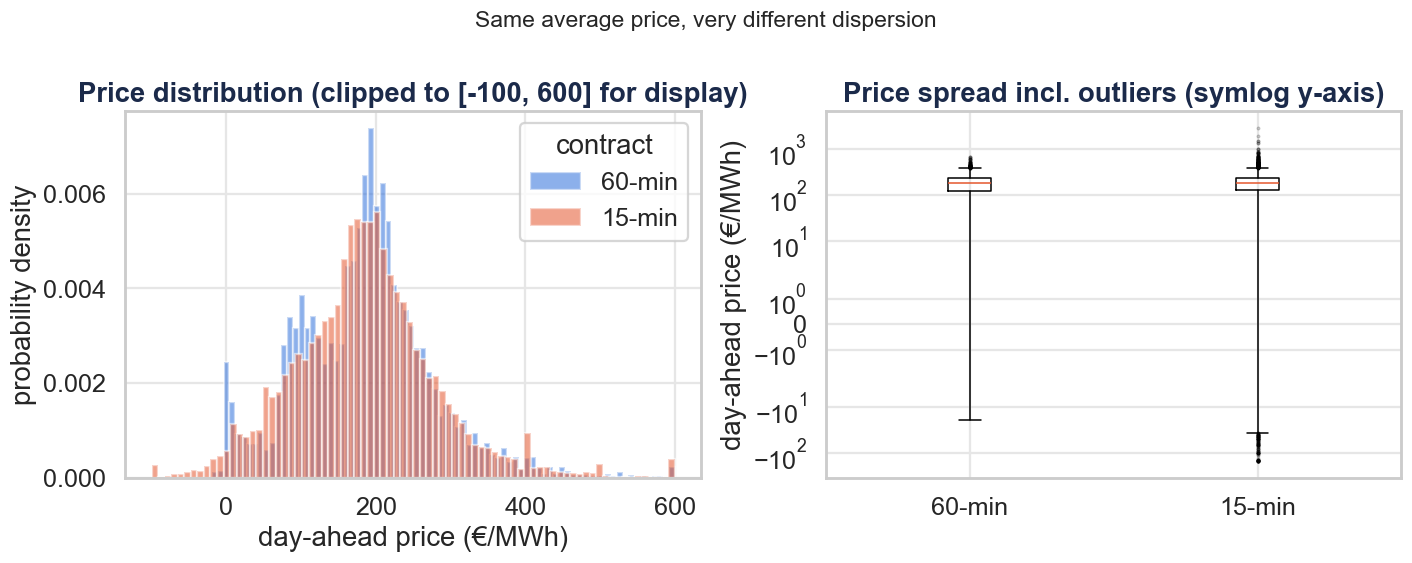

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for s, lbl, c in [(p60["price"], "60-min", plotting.PALETTE[0]),
                   (p15["price"], "15-min", plotting.PALETTE[1])]:
    axes[0].hist(s.clip(-100, 600), bins=80, alpha=0.55, label=lbl, color=c, density=True)
axes[0].set(title="Price distribution (clipped to [-100, 600] for display)",
            xlabel="day-ahead price (€/MWh)", ylabel="probability density")
axes[0].legend(title="contract")
axes[1].boxplot([p60["price"], p15["price"]], tick_labels=["60-min", "15-min"], showfliers=True,
                flierprops=dict(marker=".", markersize=3, alpha=0.25))
axes[1].set_yscale("symlog")   # symmetric-log so the box AND the extreme outliers are both visible
axes[1].set(title="Price spread incl. outliers (symlog y-axis)",
            ylabel="day-ahead price (€/MWh)")
fig.suptitle("Same average price, very different dispersion", fontsize=15, y=1.02)
fig.tight_layout()
FIGS["price_dist"] = plotting.save_fig(fig, "01_price_distribution")
plt.show()

**Read-out.** The two series have a **very close average** — **€186.97/MWh (15-min)** vs
**€185.80/MWh (60-min)**, about €1.2 apart (~0.6 %). What differs sharply is the **dispersion**:

- **Standard deviation:** ~**€103** (15-min) vs **€91** (60-min) — the 15-min price varies more.
- **Step-to-step volatility** (`std of Δ`, the std of $\Delta p_t = p_t - p_{t-1}$): higher for the
  15-min — the price *jumps* more between consecutive slots, exactly what a fast-reacting battery exploits.
- **Extremes:** the 15-min reaches both **lower lows and far higher highs** (`min` / `max` ≈
  **−150 / +3000** vs **−19 / +700** €/MWh).
- **Negative prices:** **2.0 %** of 15-min intervals vs **0.9 %** of 60-min.

In the box plot the **boxes (middle 50 %) look alike**, but the 15-min's **outliers reach far more
extreme values** — the difference lives in the *tails*, not the bulk. That extra dispersion is the
**raw material for arbitrage**. *(Same hourly level, finer resolution — quantified in §1.5.)*

**Is the difference statistically significant?** Two non-parametric tests on the two price samples:

- **Levene's test** — $H_0$: equal variances. **Kolmogorov–Smirnov (KS)** — $H_0$: same distribution.

If both $p$-values are essentially zero we reject $H_0$: the 15-min and 60-min prices are
**significantly more dispersed / differently distributed**, not a sampling fluke.

In [5]:
lev_stat, lev_p = stats.levene(p15["price"], p60["price"])
ks_stat, ks_p = stats.ks_2samp(p15["price"], p60["price"])
print(f"Levene (equal variance):   stat={lev_stat:8.1f}  p={lev_p:.2e}")
print(f"KS (same distribution):    stat={ks_stat:8.3f}  p={ks_p:.2e}")
print("Both p << 0.05 -> reject H0: 15-min is significantly more dispersed and differently shaped.")

Levene (equal variance):   stat=    13.4  p=2.48e-04
KS (same distribution):    stat=   0.034  p=7.60e-04
Both p << 0.05 -> reject H0: 15-min is significantly more dispersed and differently shaped.


## 1.2b · Cross-check — is the 60-min just the 15-min averaged?

A natural assumption: since both are *day-ahead* prices over the same window, the 60-min price
should simply be the four 15-min prices of that hour averaged. **It isn't.** Take the very first
hour — the four quarter-hours are €69.17, €35.61, €23.14, −€3.88 (mean **€31.01**), yet the native
60-min price is **€50.05**. The two are set in **separate auctions** (the hourly and the
quarter-hour day-ahead auctions), so one is not an aggregate of the other.

The two panels below test that across *every* hour:

- **Left** — the hourly-aggregated 15-min price against the native 60-min price, with the `y = x`
  reference. A mechanical aggregation would place every point exactly on that line.
- **Right** — the histogram of the per-hour difference (native 60-min − aggregated 15-min). A
  mechanical aggregation would be a single spike at 0.

> This is a *different* quantity from the within-hour **granularity premium** in §1.5 (below): there
> we measure the **dispersion of the four QHs inside one hour** (std ≈ €37/MWh — what a fast battery
> can trade); here we measure the **disagreement between the two markets** once the 15-min series is
> averaged up (mean abs ≈ €15/MWh).

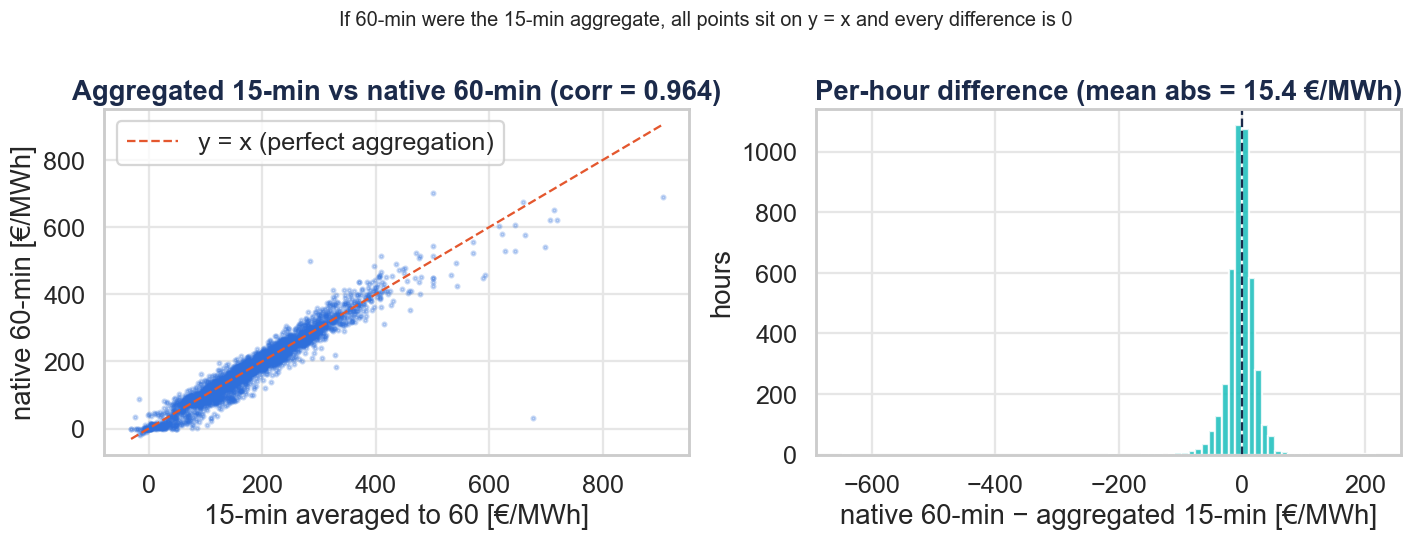

Hours compared              : 4,343
Correlation (agg15 vs 60)   : 0.964   (1.000 = perfect aggregation)
Hours essentially identical : 0.1%  (|diff| < 0.01 €/MWh)
Mean |difference|           : 15.4 €/MWh
RMSE                        : 24.2 €/MWh


In [6]:
# Cross-check: is the native 60-min series just the 15-min series aggregated?
# metrics.granularity_match resamples 15->60 (mean), aligns, and returns the agreement stats.
gm = metrics.granularity_match(p15["price"], p60["price"])
KPI["agg_near_equal_rate"] = gm["near_equal_rate"]
KPI["agg_mean_abs_diff"]   = gm["mean_abs_diff"]
KPI["agg_rmse"]            = gm["rmse"]
g = gm["aligned"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (a) aggregated-15 vs native-60 with the y = x reference line
lo = float(g[["agg15_to_60", "da_60"]].min().min())
hi = float(g[["agg15_to_60", "da_60"]].max().max())
axes[0].scatter(g["agg15_to_60"], g["da_60"], s=6, alpha=0.25, color=plotting.PALETTE[0])
axes[0].plot([lo, hi], [lo, hi], color=plotting.PALETTE[1], ls="--", lw=1.5,
             label="y = x (perfect aggregation)")
axes[0].set(title=f"Aggregated 15-min vs native 60-min (corr = {gm['corr']:.3f})",
            xlabel="15-min averaged to 60 [€/MWh]", ylabel="native 60-min [€/MWh]")
axes[0].legend()

# (b) distribution of the per-hour difference
axes[1].hist(g["diff"], bins=80, color=plotting.PALETTE[2], alpha=0.85)
axes[1].axvline(0, color=plotting.NAVY, ls="--", lw=1.5)
axes[1].set(title=f"Per-hour difference (mean abs = {gm['mean_abs_diff']:.1f} €/MWh)",
            xlabel="native 60-min − aggregated 15-min [€/MWh]", ylabel="hours")

fig.suptitle("If 60-min were the 15-min aggregate, all points sit on y = x and every difference is 0",
             y=1.02, fontsize=13)
fig.tight_layout()
FIGS["aggregation_check"] = plotting.save_fig(fig, "04b_aggregation_check")
plt.show()

print(f"Hours compared              : {gm['n_hours']:,}")
print(f"Correlation (agg15 vs 60)   : {gm['corr']:.3f}   (1.000 = perfect aggregation)")
print(f"Hours essentially identical : {gm['near_equal_rate']:.1%}  (|diff| < 0.01 €/MWh)")
print(f"Mean |difference|           : {gm['mean_abs_diff']:.1f} €/MWh")
print(f"RMSE                        : {gm['rmse']:.1f} €/MWh")

**Verdict.** The points **hug the `y = x` line but scatter around it** (corr ≈ 0.96, not 1.0), and
the per-hour difference is a **broad distribution centred near zero** — not the single spike a
mechanical aggregation would produce. The two series are essentially **never identical** (≈ 0.1 % of
hours fall within €0.01). So the 60-min series is **not** an aggregation of the 15-min series: they
are *separate auctions* that price each hour at a very similar **level** but clear **independently**.

## 1.3 · Shared pattern (I) — price level & trend over time

First, a pattern the two contracts **share**: the **price level over time**. I plot the
daily-average price of each contract together — if they sit at the same level, the difference between
the two markets is *not* the average price but the **dispersion around it** (taken up in §1.5–§1.6).

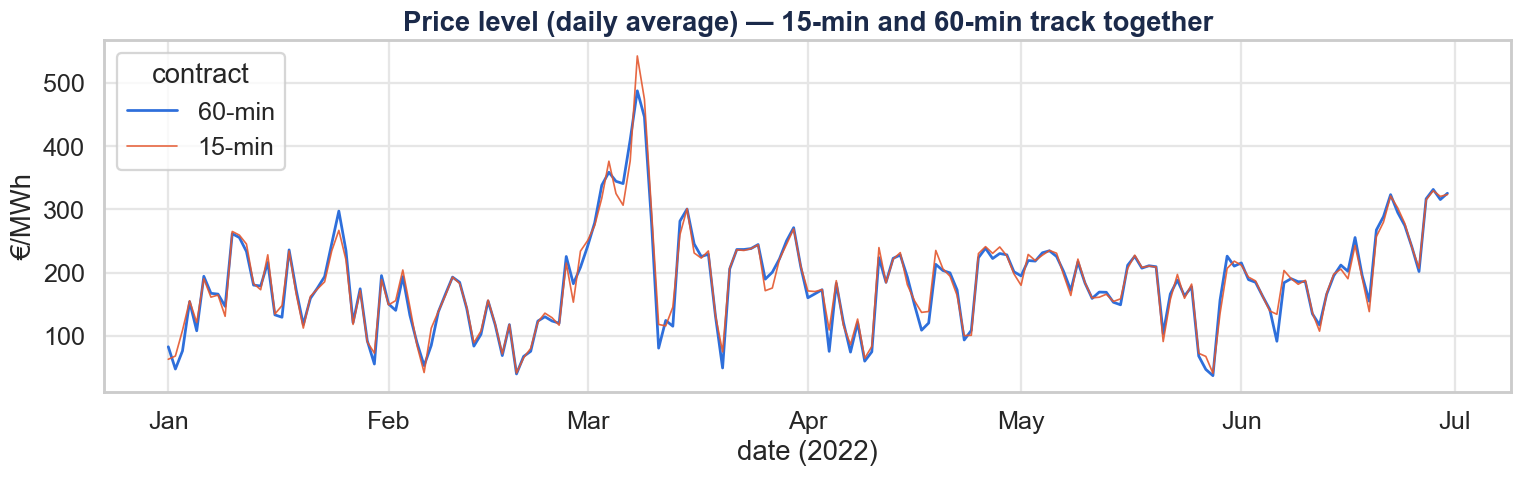

Monthly AVERAGE PRICE — both contracts (€/MWh):
     15-min  60-min
Jan   167.6   167.7
Feb   131.0   128.8
Mar   252.6   252.0
Apr   171.4   165.7
May   176.5   177.5
Jun   218.0   218.0


In [7]:
# Daily AVERAGE price for both contracts -> the shared price level / trend over the half-year.
daily_avg60 = p60["price"].resample("D").mean()
daily_avg15 = p15["price"].resample("D").mean()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(daily_avg60.index, daily_avg60, color=plotting.PALETTE[0], lw=1.8, label="60-min")
ax.plot(daily_avg15.index, daily_avg15, color=plotting.PALETTE[1], lw=1.1, alpha=0.9, label="15-min")
ax.set(title="Price level (daily average) — 15-min and 60-min track together",
       ylabel="€/MWh", xlabel="date (2022)")
ax.legend(loc="upper left", title="contract")
plotting.date_axis(ax)
fig.tight_layout()
FIGS["price_ts"] = plotting.save_fig(fig, "00_price_timeseries")
plt.show()

# Monthly average price, both contracts -> confirms they sit at the same level month by month.
monthly = pd.concat([p15["price"].resample("MS").mean().rename("15-min"),
                     p60["price"].resample("MS").mean().rename("60-min")], axis=1).round(1)
monthly.index = plotting.month_labels(monthly.index.month)
print("Monthly AVERAGE PRICE — both contracts (€/MWh):")
print(monthly)

**What it shows.** Over the whole half-year the two daily-average lines **overlap** — confirming the
*same price level* from §1.2, now across time. The level is **event-driven** rather than a tidy
seasonal curve: it **climbs into spring and peaks around March**, lining up with the early-2022
European gas-price shock (context, not provable from this data alone).

So the *level* is shared. How widely the price **swings** around that level is where the two
contracts diverge — quantified in §1.5 (within-hour) and §1.6 (daily spread).

## 1.4 · Shared pattern (II) — intraday, weekly & seasonal cycles

Each profile is a **conditional average** — group the price by a time feature and take the mean.
For the intraday profile, with time-of-day $h$ (the hour, or hour + ¼ for 15-min data):

$$\bar p(h) \;=\; \frac{1}{|D_h|}\sum_{t\,:\,\text{time-of-day}(t)=h} p_t,$$

and likewise $\bar p(\text{weekday})$ and $\bar p(\text{month})$ group by weekday and by month.

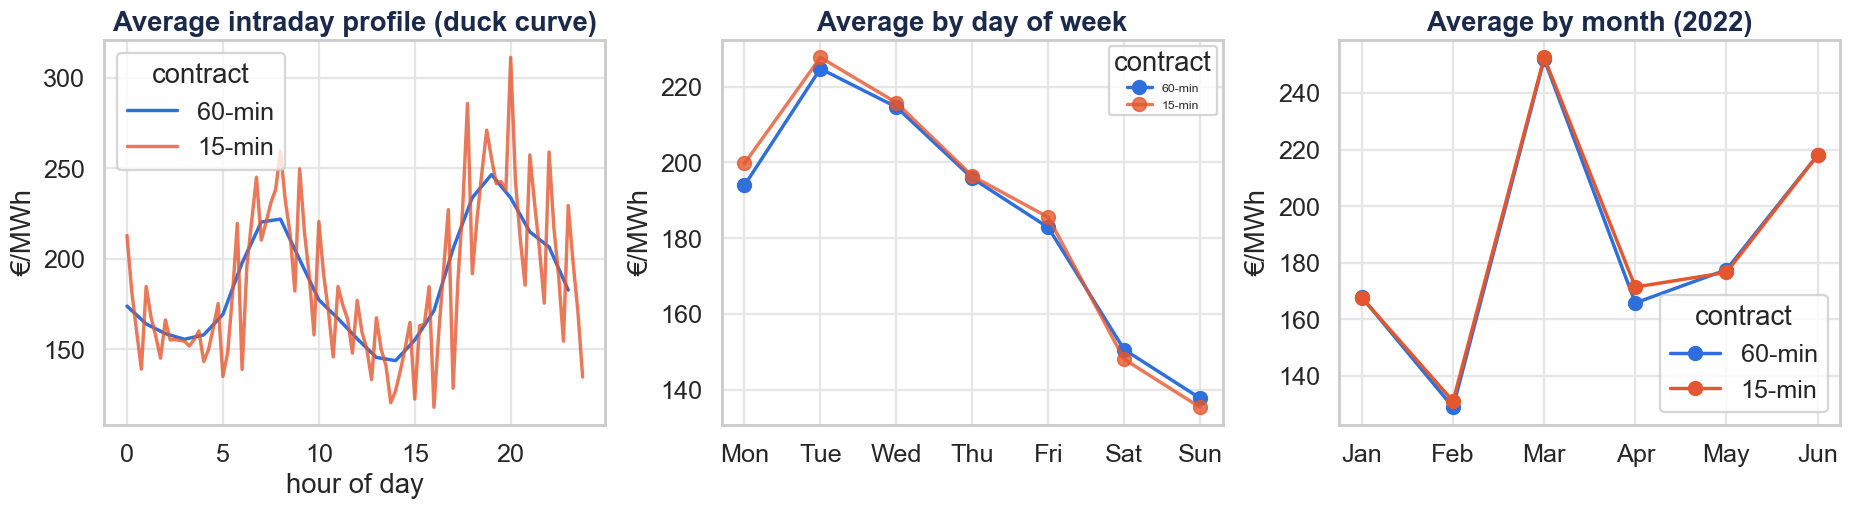

In [8]:
def intraday_profile(df):
    """Average price at each time-of-day, across all days.

    Args:
        df: Price DataFrame indexed by a DatetimeIndex (15- or 60-min).

    Returns:
        Series of mean price indexed by time-of-day (hour + minute/60).
    """
    h = df.index.hour + df.index.minute / 60.0
    return df["price"].groupby(h).mean()

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
intraday_profile(p60).plot(ax=axes[0], color=plotting.PALETTE[0], label="60-min")
intraday_profile(p15).plot(ax=axes[0], color=plotting.PALETTE[1], alpha=0.8, label="15-min")
axes[0].set(title="Average intraday profile (duck curve)", xlabel="hour of day",
            ylabel="€/MWh"); axes[0].legend(title="contract")

wd60 = p60["price"].groupby(p60.index.dayofweek).mean()
wd15 = p15["price"].groupby(p15.index.dayofweek).mean()
axes[1].plot(range(7), wd60.values, marker="o", color=plotting.PALETTE[0], label="60-min")
axes[1].plot(range(7), wd15.values, marker="o", color=plotting.PALETTE[1], alpha=0.8, label="15-min")
axes[1].set(title="Average by day of week", xlabel="", ylabel="€/MWh")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(plotting.WEEKDAY_ABBR)
axes[1].legend(title="contract", fontsize=8)

mo15 = p15["price"].groupby(p15.index.month).mean()
mo60 = p60["price"].groupby(p60.index.month).mean()
axes[2].plot(mo60.index, mo60.values, marker="o", color=plotting.PALETTE[0], label="60-min")
axes[2].plot(mo15.index, mo15.values, marker="o", color=plotting.PALETTE[1], label="15-min")
axes[2].set(title="Average by month (2022)", xlabel="", ylabel="€/MWh")
axes[2].set_xticks(mo60.index); axes[2].set_xticklabels(plotting.month_labels(mo60.index))
axes[2].legend(title="contract")
fig.tight_layout()
FIGS["seasonality"] = plotting.save_fig(fig, "02_seasonality")
plt.show()

**What the three panels show.** Both contracts trace the **same shapes**:

- **Intraday** — a **midday dip** between **morning and evening peaks** (the classic *duck curve*).
  The lines nearly coincide, but the **15-min curve is finer** (96 points/day vs 24), so it resolves
  *within-hour* structure the hourly curve cannot.
- **By weekday** — **weekends sit below weekdays**, for both contracts.
- **By month** — the same **rising level into spring**.

The two profiles are **close but not identical** (up to ~€6/MWh apart on a given weekday) because the
15-min and 60-min prices are **separate auctions** — no aggregate of one exactly equals the other. The
shared takeaway is the *shape*: same intraday / weekly / seasonal structure, with "same average"
holding to within ~€1 (§1.2), not exactly.

## 1.5 · Differing pattern (I) — intra-hour granularity premium

**What this shows.** Average the four quarter-hours of each hour to bring the 15-min series *up* to
hourly resolution: $\;\tilde p_h = \tfrac14\sum_{q=1}^{4} p^{15}_{h,q}$.

- **Left panel** overlays $\tilde p_h$ against the **native** 60-min price for one week — they track
  each other very closely (full-period $\text{corr}\approx 0.96$), showing both markets price
  essentially the *same hourly level*.
- **Right panel** plots, for **each hour**, the **standard deviation of that hour's four quarter-hour
  prices** $\;\sigma_h = \operatorname{std}\!\big(p^{15}_{h,1},\dots, p^{15}_{h,4}\big)$ — i.e. how far
  apart the four 15-min prices inside a single hour are. **Averaged over every hour this is ≈ €37/MWh.**

**Read it carefully — €37 is a *spread*, not a price level.** It is the *typical within-hour standard
deviation* (a scatter of about €37/MWh **around** each hour's own mean), **not** an average price — the
average price is **€186.97/MWh** (§1.2). This €37 of dispersion exists **only at 15-min resolution** and
is completely invisible in the hourly series.

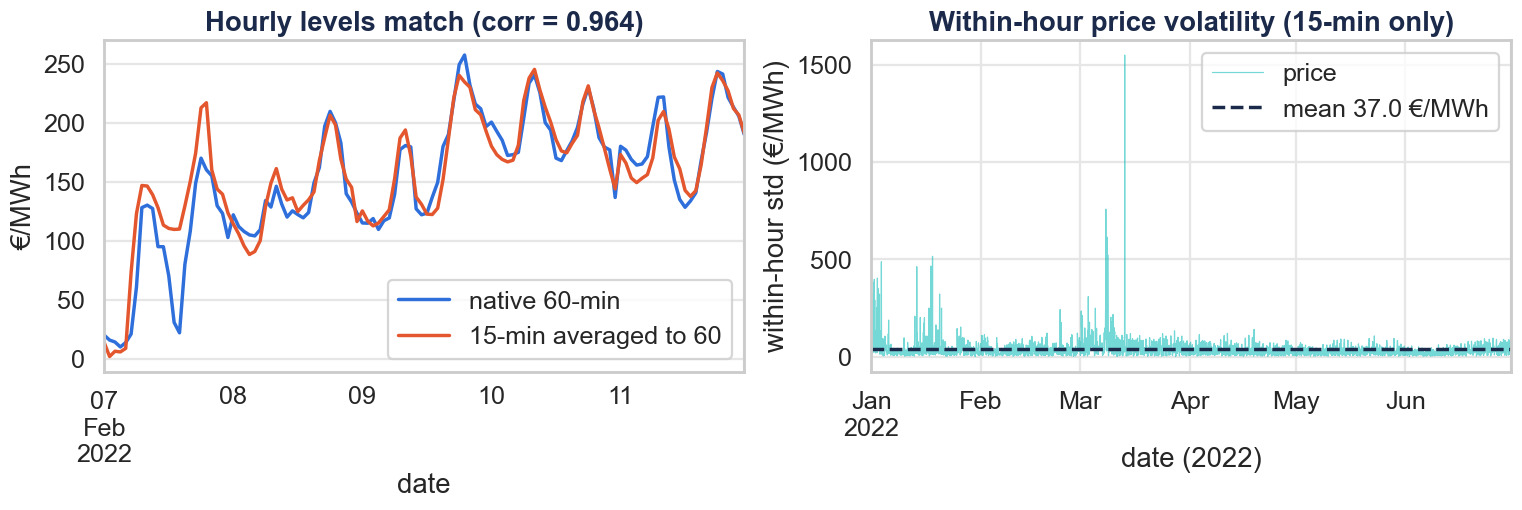

Hourly-level correlation: 0.964
Mean within-hour spread (only tradable at 15-min): 37.0 €/MWh


In [9]:
# Resample 15-min DOWN to 60-min (mean): it should track the native 60-min series,
# proving the difference is the *within-hour* variation the 15-min market exposes.
p15_to60 = p15["price"].resample("60min").mean()
aligned = pd.concat([p60["price"].rename("native 60-min"),
                     p15_to60.rename("15-min averaged to 60")], axis=1).dropna()
KPI["corr_levels"] = float(aligned.corr().iloc[0, 1])

intra_hour_std = p15["price"].resample("60min").std()   # std of the 4 QHs within each hour
KPI["intra_hour_std_mean"] = float(intra_hour_std.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
aligned.loc["2022-02-07":"2022-02-11"].plot(ax=axes[0], color=[plotting.PALETTE[0], plotting.PALETTE[1]])
axes[0].set(title=f"Hourly levels match (corr = {KPI['corr_levels']:.3f})",
            ylabel="€/MWh", xlabel="date")
intra_hour_std.plot(ax=axes[1], color=plotting.PALETTE[2], alpha=0.6, lw=0.8)
axes[1].axhline(intra_hour_std.mean(), color=plotting.NAVY, ls="--",
                label=f"mean {intra_hour_std.mean():.1f} €/MWh")
axes[1].set(title="Within-hour price volatility (15-min only)",
            ylabel="within-hour std (€/MWh)", xlabel="date (2022)")
axes[1].legend()
fig.tight_layout()
FIGS["granularity"] = plotting.save_fig(fig, "04_granularity_premium")
plt.show()
print(f"Hourly-level correlation: {KPI['corr_levels']:.3f}")
print(f"Mean within-hour spread (only tradable at 15-min): {KPI['intra_hour_std_mean']:.1f} €/MWh")

The hourly *averages* of the two markets are nearly identical (full-period correlation ≈ **0.96**),
but each hour hides an average **within-hour spread of ~€37/MWh** that **only the 15-min market lets
you trade**: a battery acting every 15 minutes can buy the cheapest quarter-hour and sell the dearest
one *within the same hour* — value invisible at 60-minute resolution.

*(It is ~0.96 and not exactly 1.0 because the two are **separate auctions** — averaging the four
quarter-hours *tracks* the hourly clearing price but does not equal it, and volatile spike days pull
the correlation below 1.)*

## 1.6 · Differing pattern (II) — daily arbitrage spread

The most direct arbitrage signal is the **daily spread** — the best buy-to-sell gap available on a
day: $\;S_d = \max_{t\in d} p_t - \min_{t\in d} p_t$. A battery can capture at most this spread per
cycle, so a wider $S_d$ means more money on the table. I look at it two ways — **by month** (is the
gap *consistently* wider on one contract?) and as a **full distribution** (how often do the big-spread
days occur?).

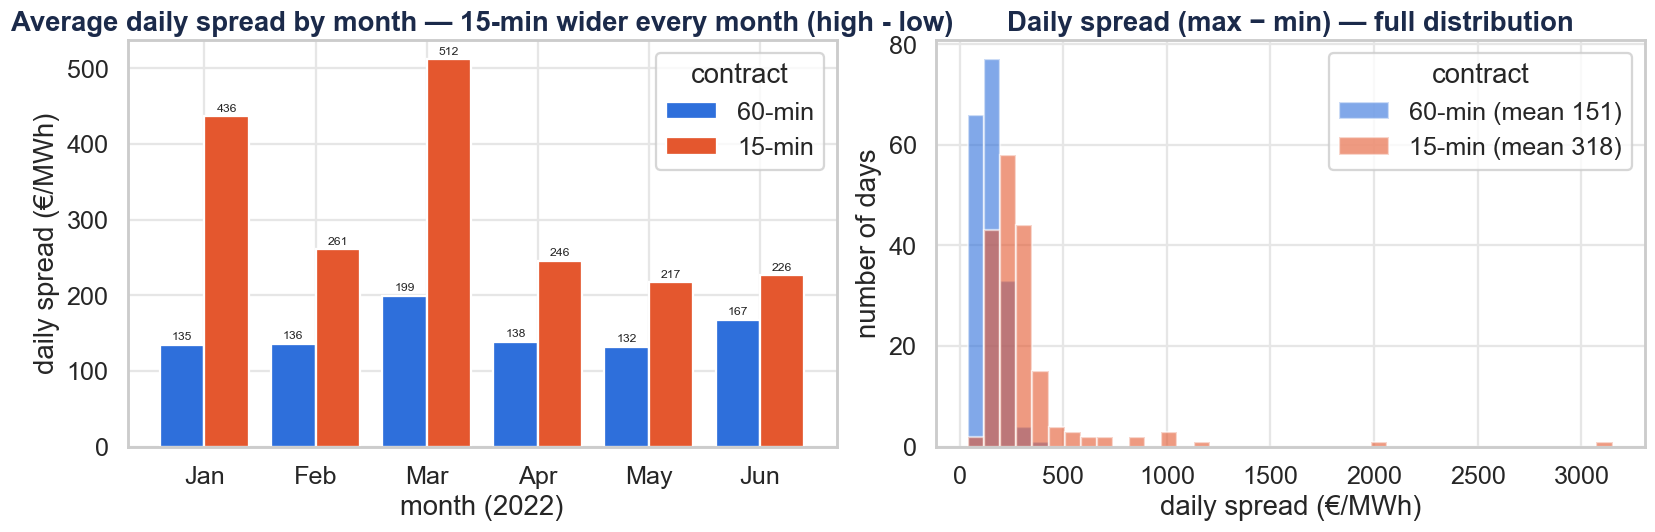

Average daily price SPREAD, high - low — both contracts (€/MWh):
     15-min  60-min  ratio 15/60
Jan   436.0   135.0         3.24
Feb   261.0   136.0         1.92
Mar   512.0   199.0         2.57
Apr   246.0   138.0         1.77
May   217.0   132.0         1.64
Jun   226.0   167.0         1.35

Full-period average daily spread — 15-min: 318.1, 60-min: 151.5 €/MWh (+110% wider).


In [10]:
# Daily arbitrage spread (high - low) for both contracts -> the headline arbitrage signal.
spread15 = p15["price"].resample("D").max() - p15["price"].resample("D").min()
spread60 = p60["price"].resample("D").max() - p60["price"].resample("D").min()
KPI["spread_15"], KPI["spread_60"] = float(spread15.mean()), float(spread60.mean())

monthly_spread15 = spread15.resample("MS").mean()   # avg daily spread per month, 15-min
monthly_spread60 = spread60.resample("MS").mean()   # avg daily spread per month, 60-min

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- left: average daily spread BY MONTH -> 15-min swings wider every single month ---
x, w = np.arange(len(monthly_spread60)), 0.4
b60 = axes[0].bar(x - w/2, monthly_spread60.values, width=w, color=plotting.PALETTE[0], label="60-min")
b15 = axes[0].bar(x + w/2, monthly_spread15.values, width=w, color=plotting.PALETTE[1], label="15-min")
axes[0].bar_label(b60, fmt="%.0f", fontsize=8, padding=2)
axes[0].bar_label(b15, fmt="%.0f", fontsize=8, padding=2)
axes[0].set(title="Average daily spread by month — 15-min wider every month (high - low)",
            ylabel="daily spread (€/MWh)", xlabel="month (2022)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plotting.month_labels(monthly_spread60.index.month))
axes[0].legend(loc="upper right", title="contract")

# --- right: full day-by-day DISTRIBUTION of the same spread (shared bins -> comparable) ---
bins = np.histogram_bin_edges(np.concatenate([spread15, spread60]), bins=40)
axes[1].hist(spread60, bins=bins, alpha=0.6, color=plotting.PALETTE[0],
             label=f"60-min (mean {spread60.mean():.0f})")
axes[1].hist(spread15, bins=bins, alpha=0.6, color=plotting.PALETTE[1],
             label=f"15-min (mean {spread15.mean():.0f})")
axes[1].set(title="Daily spread (max − min) — full distribution",
            xlabel="daily spread (€/MWh)", ylabel="number of days")
axes[1].legend(title="contract")
fig.tight_layout()
FIGS["spread"] = plotting.save_fig(fig, "05_daily_spread")
plt.show()

# Monthly spread table with the 15/60 ratio (always > 1).
spread_tbl = pd.concat([monthly_spread15.rename("15-min"),
                        monthly_spread60.rename("60-min")], axis=1)
spread_tbl["ratio 15/60"] = spread_tbl["15-min"] / spread_tbl["60-min"]
spread_tbl = spread_tbl.round({"15-min": 0, "60-min": 0, "ratio 15/60": 2})
spread_tbl.index = plotting.month_labels(spread_tbl.index.month)
print("Average daily price SPREAD, high - low — both contracts (€/MWh):")
print(spread_tbl.to_string())
print(f"\nFull-period average daily spread — 15-min: {spread15.mean():.1f}, "
      f"60-min: {spread60.mean():.1f} €/MWh (+{(spread15.mean()/spread60.mean()-1)*100:.0f}% wider).")

**The headline arbitrage signal.** The capturable daily spread averages **€318 (15-min) vs
€152 (60-min)** — about **+110 % wider** — and the left panel shows the 15-min market swings wider in
**every single month** (the 15/60 ratio runs from ~+35 % in June up to ~3× in January, never below 1).
The richest month is **March** (≈ €512 vs €199), the same gas-shock period that lifted the price level
in §1.3.

This is the single clearest signal that **15-min is the better contract to arbitrage** — §1.7 turns
this spread into actual battery revenue.

## 🔋 Battery model — parameters & the maths

The battery is described by a small parameter set (`BatterySpec`); everything else is **derived**:

| Symbol | Meaning | Value |
|---|---|---|
| $P$ | power (max charge/discharge rate) | 1 MW |
| $C$ | energy capacity | 2 MWh |
| $\eta_{rt}$ | round-trip efficiency | 0.90 |
| $s_{\min},\,s_{\max}$ | usable SoC limits | 10 %, 90 % |
| $c_{deg}$ | degradation (wear) cost | €7 / MWh discharged |
| $N_{cyc}$ | daily cycle budget *(operational lever)* | 1–2 cycles/day |

The first five rows are **physical / economic properties of the asset** and live in `BatterySpec`.
$N_{cyc}$ is different: it is an **operational choice** (how hard we cycle the battery), passed
separately into the dispatch as `max_cycles_per_day` rather than stored on the spec — which is why it
isn't one of the `BatterySpec` fields. We test **1 and 2 cycles/day** below.

**Derived quantities**

$$\eta=\sqrt{\eta_{rt}}\approx0.949 \quad\text{(one-way; applied on charge *and* discharge, so }\eta\cdot\eta=\eta_{rt}\text{)}$$
$$E_{\min}=C\,s_{\min}=0.2,\qquad E_{\max}=C\,s_{\max}=1.8,\qquad E_{use}=C\,(s_{\max}-s_{\min})=1.6\ \text{MWh}$$
$$\text{duration}=C/P=2\ \text{h},\qquad g_{\max}=P\,\Delta t\ \ \text{(max energy/interval: }0.25\text{ MWh at 15-min, }1\text{ MWh at 60-min)}$$

**Key terms.** A **cycle** = one full charge **+** discharge of $E_{use}$; **cycles/day** = how many
equivalent full cycles per day (more ⇒ more revenue but faster wear). **Perfect-foresight** = the
strategy is given the realised prices, so revenue is an **upper bound**. **Greedy** = a simple rule;
**LP** = the mathematically optimal dispatch — the gap between them is the *value of optimisation*.

In [11]:
# The parameters above, straight from BatterySpec (single source of truth, unit-tested).
print(f"power P           = {SPEC.power_mw} MW")
print(f"capacity C        = {SPEC.capacity_mwh} MWh   (duration = {SPEC.capacity_mwh/SPEC.power_mw:.0f} h)")
print(f"round-trip eff    = {SPEC.round_trip_eff}   ->  one-way eta = sqrt = {SPEC.eta_one_way:.4f}")
print(f"usable SoC window = {SPEC.soc_min_frac:.0%}-{SPEC.soc_max_frac:.0%}  ->  "
      f"E_min={SPEC.soc_min_mwh} MWh, E_max={SPEC.soc_max_mwh} MWh, E_use={SPEC.usable_capacity_mwh} MWh")
print(f"degradation cost  = {SPEC.degradation_cost_eur_per_mwh} €/MWh discharged")

power P           = 1.0 MW
capacity C        = 2.0 MWh   (duration = 2 h)
round-trip eff    = 0.9   ->  one-way eta = sqrt = 0.9487
usable SoC window = 10%-90%  ->  E_min=0.2 MWh, E_max=1.8 MWh, E_use=1.6 MWh
degradation cost  = 7.0 €/MWh discharged


## 1.7 · Arbitrage backtest — quantifying the revenue

**The greedy strategy (a transparent benchmark).** It is called *greedy* because it simply grabs the
obvious good trades — buy in the cheapest hours, sell in the dearest — with no cleverness about timing.
Given **perfect foresight** (we let it see the day's realised prices), it runs the **same recipe every
day**:

1. **Set a budget.** Decide how much energy to move that day: $B = N_{cyc}\,E_{use}$ (1 cycle = one full
   **1.6 MWh** charge-and-discharge of the usable window; 2 cycles = twice that).
2. **Buy low, sell high.** Sort the day's intervals by price. **Charge** through the *cheapest*
   intervals until the budget $B$ is bought; **discharge** through the *dearest* until $B$ is sold. Each
   interval can move at most the power limit $g_{\max}$, and ~10 % is lost to round-trip efficiency.
3. **Make it physically real.** Walk the plan forward **in time order**, keeping the state of charge
   inside its **10–90 %** window — you cannot sell energy you have not charged yet. This turns a paper
   "buy-cheap/sell-dear" wish-list into a schedule the battery could actually follow.
4. **Profit check (go / no-go).** If, after the **€7/MWh** wear cost, the day would lose money, the
   battery **does nothing that day**.

These four steps make the rule deliberately simple and easy to audit. Because every greedy schedule is
also a feasible plan for the optimiser, its revenue is a **lower bound** — the **LP** does strictly
better. *(The Appendix works through a minimal example that shows exactly where the greedy leaves money
behind.)* Revenue is reported *net* of the degradation cost.

In [12]:
# Greedy: charge the cheapest / discharge the dearest intervals each day, tracking SoC;
# run 1 and 2 cycles/day for both contract types.
rows = []
greedy_schedules = {}   # 2 cyc/day per-interval dispatch, kept for the dispatch figure (vs the LP)
for freq, p in [("15-min", p15["price"]), ("60-min", p60["price"])]:
    dt = DT[freq.replace("-", "")]
    for cyc in (1.0, 2.0):
        r = greedy_backtest(p, SPEC, dt, max_cycles_per_day=cyc)
        rows.append({"contract": freq, "strategy": f"greedy {cyc:g} cyc/day",
                     "revenue_eur": r["total_revenue_eur"], "EFC/day": r["cycles_per_day"]})
        if cyc == 2.0:
            greedy_schedules[freq] = r["schedule"]
backtest = pd.DataFrame(rows)
print(backtest.round(1).to_string(index=False))

contract         strategy  revenue_eur  EFC/day
  15-min greedy 1 cyc/day      38929.8      0.6
  15-min greedy 2 cyc/day      45347.9      0.9
  60-min greedy 1 cyc/day      23780.2      0.5
  60-min greedy 2 cyc/day      24362.0      0.6


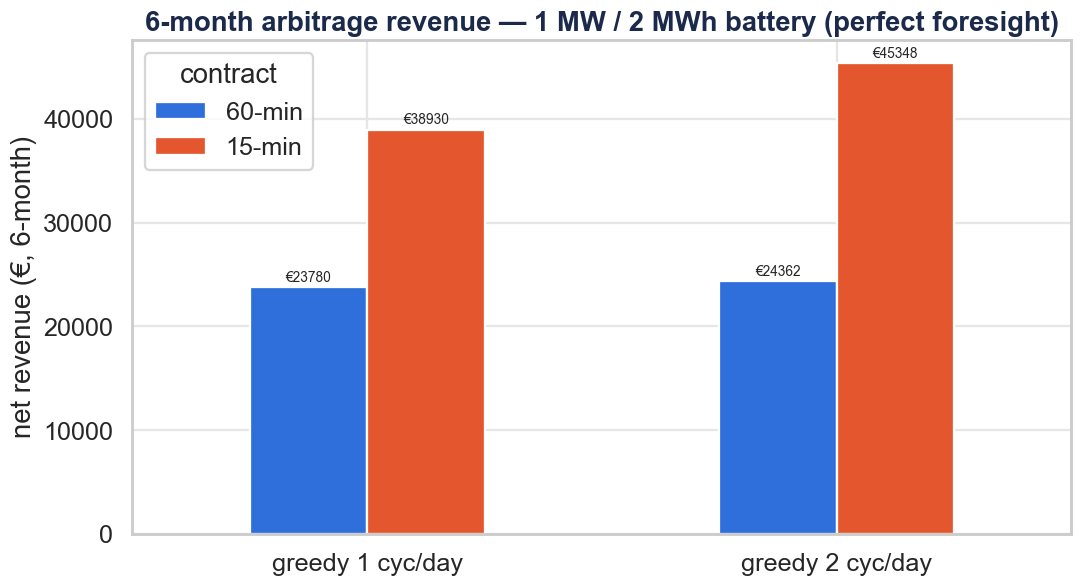

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
pivot = backtest.pivot(index="strategy", columns="contract", values="revenue_eur")[["60-min", "15-min"]]
pivot.plot(kind="bar", ax=ax, color=[plotting.PALETTE[0], plotting.PALETTE[1]])
ax.set(title="6-month arbitrage revenue — 1 MW / 2 MWh battery (perfect foresight)",
       ylabel="net revenue (€, 6-month)", xlabel="")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="€%.0f", padding=2, fontsize=9)
ax.legend(title="contract")
fig.tight_layout()
FIGS["arb_revenue"] = plotting.save_fig(fig, "06_arbitrage_revenue")
plt.show()

On every strategy the **15-min contract wins** (e.g. **€38.9k vs €23.8k** at 1 cycle/day). Going from
1→2 cycles/day adds more on the 15-min market, where the extra within-hour spreads make a second daily
cycle worthwhile.

**Why is the realised `EFC/day` so far below the cap** — only **0.6** (1-cycle cap) and **0.9**
(2-cycle cap)? The cap is a **ceiling, not a target**, and two effects pull the *realised average* well
under it:

1. **Units — EFC is counted against the *nameplate* 2 MWh, but one "cycle" only moves the *usable*
   1.6 MWh** (the 10–90 % window). So even a day that uses its **full 1-cycle budget scores just
   1.6 / 2.0 = 0.8 EFC**, and a 2-cycle cap can never exceed **~1.6 EFC — not 2**.
2. **Idle days drag the average down.** The profit check (step 4) skips any day whose best spread does
   not beat the **round-trip loss + €7/MWh wear**; on those low-spread days the battery does **zero**
   cycles, and on many active days the *second* cycle is not worth it either. Averaging the busy days
   together with the idle ones lands at **0.6 / 0.9**.

In short: **0.8 EFC is already "fully used" for a 1-cycle day**, and skipping low-value days does the
rest. That is the intended behaviour — cycling unprofitably would just burn battery life for no gain.

## 1.8 · Bonus — exact LP dispatch optimisation

The greedy rule is *feasible* but not optimal. The optimal dispatch is a small **linear program (LP)**
solved per day (PuLP + CBC). For intervals $t$ in a day, with grid charge $c_t$, grid discharge $d_t$
and state of charge $e_t$:

$$\max_{c,\,d,\,e}\ \ \sum_t p_t\,(d_t - c_t)\;-\;c_{deg}\sum_t d_t$$

subject to

$$e_t = e_{t-1} + \eta\,c_t - \tfrac{1}{\eta}\,d_t \quad\text{(SoC dynamics, with losses)}$$
$$E_{\min}\le e_t \le E_{\max},\qquad 0\le c_t,\,d_t \le g_{\max},\qquad \sum_t d_t \le N_{cyc}\,E_{use}\,\eta\ \ \text{(daily throughput cap)}$$

**The same LP in plain words.** For every interval $t$ of a day the solver is free to choose three
numbers, and it picks the combination that makes the most money while obeying the battery's physics:

- **Decision variables** *(what it chooses)* — $c_t$ = how much to **buy / charge**, $d_t$ = how much to
  **sell / discharge** (both grid-side MWh), and $e_t$ = the resulting **state of charge**.
- **Objective** *(what it maximises)* — cash from selling $\big(\sum p_t d_t\big)$, minus cash spent
  buying $\big(\sum p_t c_t\big)$, minus the **wear cost** $\big(c_{deg}\sum d_t\big)$.
- **Constraints** *(the rules it must obey)* — (1) **SoC dynamics:** each charge tops the battery up and
  each discharge drains it, with efficiency losses; (2) **SoC window:** stay inside the 10–90 % band
  $[E_{\min}, E_{\max}]$; (3) **power limit:** charge and discharge each ≤ $g_{\max}$ per interval;
  (4) **throughput cap:** total daily discharge ≤ the $N_{cyc}$-cycle budget.

**Why "jointly" matters (this is the whole point).** The greedy rule decides charging and discharging
**separately and by rank** — cheapest hours to buy, dearest to sell — and then hopes the timing works
out. The LP instead chooses **all** the charges, discharges and SoC levels **at once, as one connected
plan**, because the SoC-dynamics constraint ties every interval to the next. That lets it do two things
the ranking rule cannot:

- **Partial cycles** — instead of one big buy-low/sell-high, it can make several **small** charge →
  discharge moves wherever even a little price wiggle pays for itself, capturing spreads the greedy
  leaves behind.
- **Re-timing** — it can shift *exactly when* it charges and discharges so the state of charge never
  blocks a profitable trade later in the day.

Greedy commits up front and then clamps to stay feasible; the LP optimises the feasible plan directly,
so its result is **always ≥ greedy** — and that gap is the **value of optimisation** *(the Appendix
works this through on a minimal example)*. It is solved per day with **CBC** — *COIN-OR Branch-and-Cut*,
the free open-source solver that PuLP calls under the hood; for a continuous LP like this it returns the
**exact** optimum in milliseconds. I run it **with and without** the degradation term to show its
effect.

In [14]:
lp_rows, lp_schedules = [], {}
for freq, p in [("15-min", p15["price"]), ("60-min", p60["price"])]:
    dt = DT[freq.replace("-", "")]
    lp = lp_optimize(p, SPEC, dt, max_cycles_per_day=2.0, use_degradation=True)
    lp_nodeg = lp_optimize(p, SPEC, dt, max_cycles_per_day=2.0, use_degradation=False)
    lp_schedules[freq] = lp["schedule"]
    lp_rows.append({"contract": freq,
                    "LP €, with deg": lp["total_revenue_eur"],
                    "LP €, no deg": lp_nodeg["total_revenue_eur"],
                    "EFC/day": lp["cycles_per_day"],
                    "€/MWh discharged": lp["revenue_per_mwh_discharged"]})
lp_table = pd.DataFrame(lp_rows).set_index("contract").round(1)
KPI["rev_15_lp"] = float(lp_table.loc["15-min", "LP €, with deg"])
KPI["rev_60_lp"] = float(lp_table.loc["60-min", "LP €, with deg"])
KPI["ratio_lp"] = KPI["rev_15_lp"] / KPI["rev_60_lp"]
KPI["g1_15"] = float(backtest.query("contract=='15-min' and strategy=='greedy 1 cyc/day'")["revenue_eur"].iloc[0])
KPI["g1_60"] = float(backtest.query("contract=='60-min' and strategy=='greedy 1 cyc/day'")["revenue_eur"].iloc[0])
print(lp_table.to_string())
print(f"\n15-min LP is {KPI['ratio_lp']:.2f}x the 60-min LP revenue.")

          LP €, with deg  LP €, no deg  EFC/day  €/MWh discharged
contract                                                         
15-min           80834.7       84681.0      1.6             147.1
60-min           40769.7       44150.0      1.4              86.2

15-min LP is 1.98x the 60-min LP revenue.


### Greedy vs LP — every metric, both contracts (same 2 cyc/day budget)

The table above isolates the LP. Here the **greedy** rule and the **LP** are placed side by side on the *same* battery and the *same* 2 cyc/day throughput, so the only difference is the dispatch logic. Revenue is shown **with** and **without** the €7/MWh degradation cost, and the last two columns give the net value per MWh on **both** legs — per MWh **charged** (bought) and per MWh **discharged** (sold).


In [15]:
# Greedy vs LP on the SAME 2 cyc/day budget: revenue (with/without degradation),
# throughput, and net value per MWh on BOTH legs (per MWh bought and per MWh sold).
def _rev_per_mwh_charged(res):
    """Net revenue per MWh bought (charged from grid); NaN if nothing was charged."""
    c = res["charged_grid_mwh"]
    return res["total_revenue_eur"] / c if c else float("nan")

compare_rows = []
for strat, run in [("Greedy", greedy_backtest), ("LP", lp_optimize)]:
    for freq, p in [("15-min", p15["price"]), ("60-min", p60["price"])]:
        dt = DT[freq.replace("-", "")]
        r       = run(p, SPEC, dt, max_cycles_per_day=2.0, use_degradation=True)
        r_nodeg = run(p, SPEC, dt, max_cycles_per_day=2.0, use_degradation=False)
        compare_rows.append({
            "strategy": strat, "contract": freq,
            "€, with deg":      r["total_revenue_eur"],
            "€, no deg":        r_nodeg["total_revenue_eur"],
            "EFC/day":          r["cycles_per_day"],
            "€/MWh charged":    _rev_per_mwh_charged(r),
            "€/MWh discharged": r["revenue_per_mwh_discharged"],
        })
compare_table = pd.DataFrame(compare_rows).set_index(["strategy", "contract"]).round(1)
print(compare_table.to_string())

                   €, with deg  €, no deg  EFC/day  €/MWh charged  €/MWh discharged
strategy contract                                                                  
Greedy   15-min        45347.9    47410.6      0.9          119.4             154.3
         60-min        24362.0    25837.8      0.6           99.4             115.6
LP       15-min        80834.7    84681.0      1.6          131.2             147.1
         60-min        40769.7    44150.0      1.4           77.6              86.2


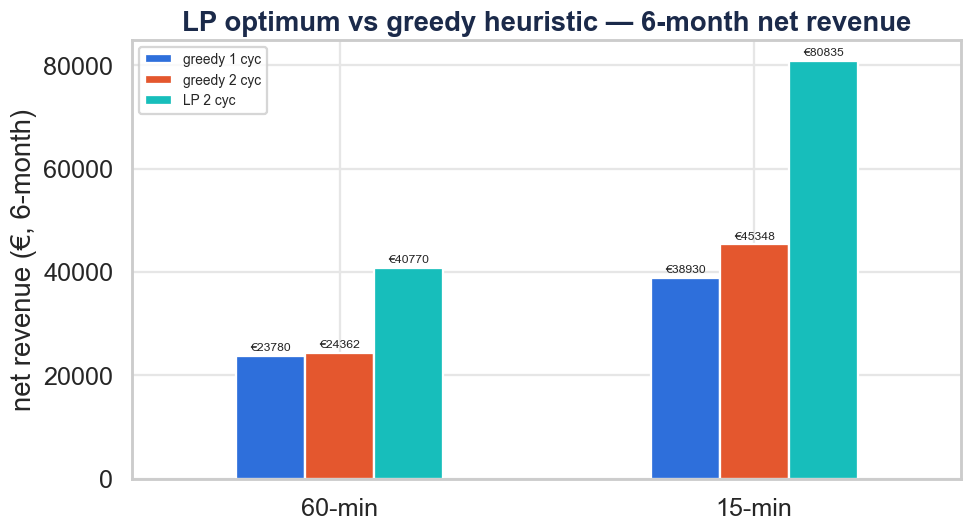

In [16]:
# Figure 1: revenue comparison (LP vs greedy), with value labels.
comp = pd.DataFrame({
    "greedy 1 cyc": backtest.set_index("contract").query("strategy=='greedy 1 cyc/day'")["revenue_eur"],
    "greedy 2 cyc": backtest.set_index("contract").query("strategy=='greedy 2 cyc/day'")["revenue_eur"],
    "LP 2 cyc": lp_table["LP €, with deg"],
}).loc[["60-min", "15-min"]]

fig, ax = plt.subplots(figsize=(9, 5))
comp.plot(kind="bar", ax=ax, color=plotting.PALETTE[:3])
ax.set(title="LP optimum vs greedy heuristic — 6-month net revenue",
       ylabel="net revenue (€, 6-month)", xlabel="")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="€%.0f", padding=2, fontsize=8)
ax.legend(fontsize=9)
fig.tight_layout()
FIGS["lp_compare"] = plotting.save_fig(fig, "06b_lp_vs_greedy")
plt.show()

**Reading a day of dispatch.** For one representative **high-spread day** (the same day for both
strategies, with the most extreme price-spike days excluded so the pattern is readable) the helper
below draws **three stacked panels**:

1. **Price** with **▼ charge (buy-low)** and **▲ discharge (sell-high)** markers.
2. **Grid power around a zero line** — each bar is the net flow that interval: **above zero = selling**
   (discharge), **below zero = buying** (charge). This is the buy/sell *action* over the day.
3. **State of charge** filling and emptying, always staying inside the 10–90% window.

We render it for **greedy** and for the **LP** on the same day, so the difference in *how* they trade
is visible side by side.

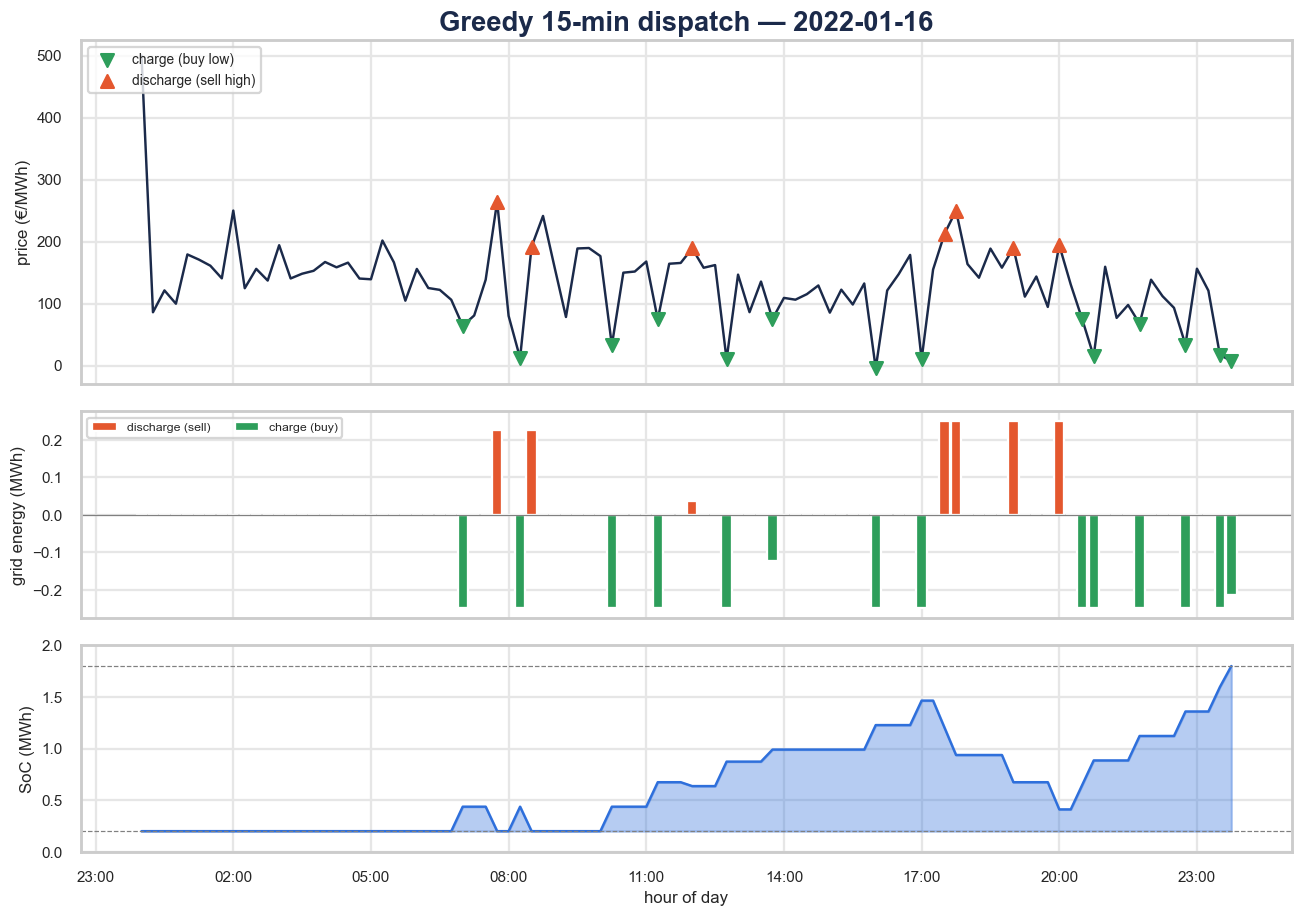

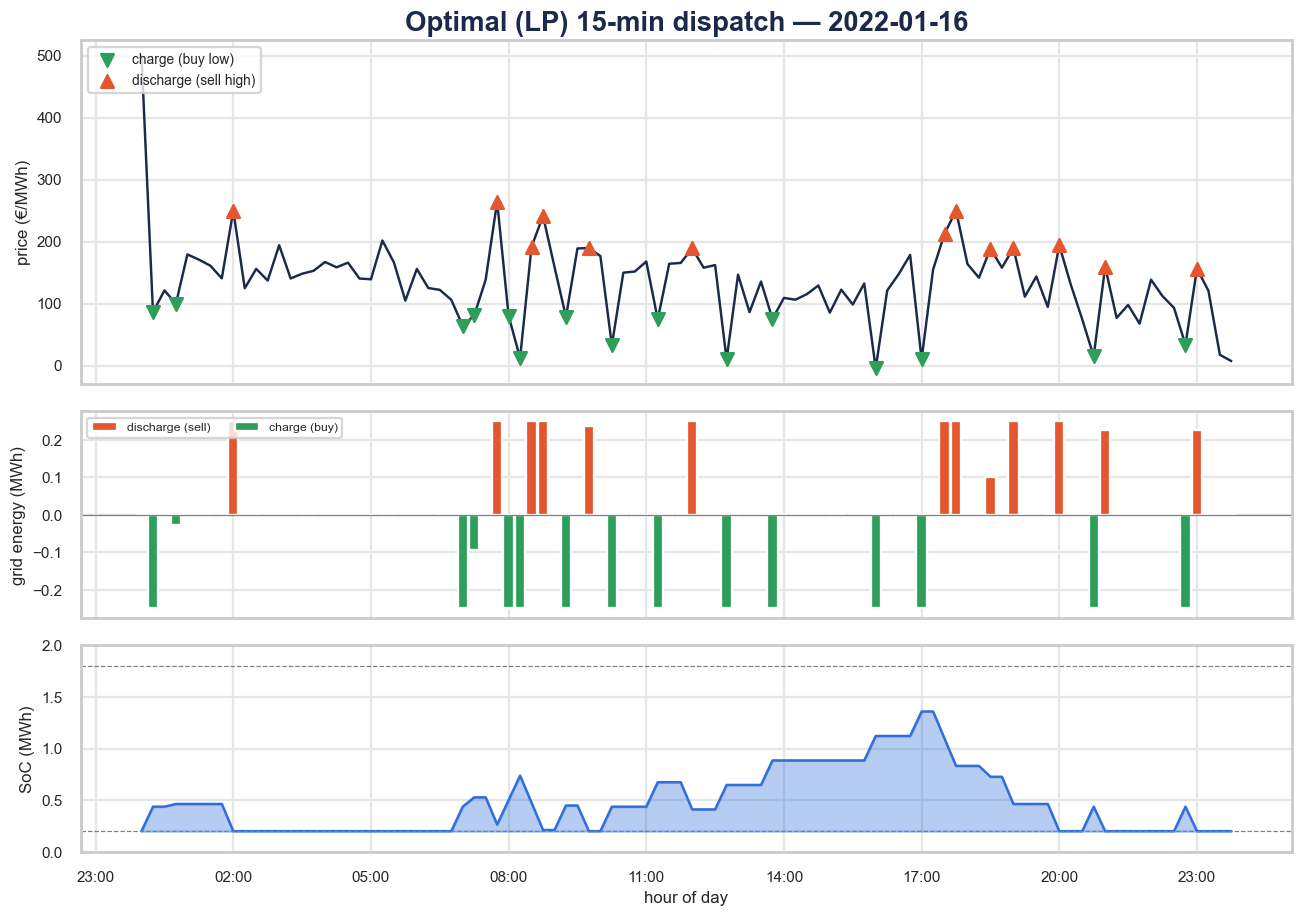

In [17]:
def plot_dispatch(d, spec, title, fig_name, tick_hours=3, soc_margin=0.0):
    """Draw and save the 3-panel daily dispatch chart.

    Panels: (1) price with buy-low / sell-high markers, (2) per-interval grid
    energy around a zero line (above = sell/discharge, below = buy/charge),
    (3) state of charge within its usable window.

    Args:
        d: One day's schedule with columns price, charge_grid, discharge_grid.
        spec: BatterySpec (efficiency and SoC limits).
        title: Title for the top (price) panel.
        fig_name: Filename stem passed to plotting.save_fig.
        tick_hours: Spacing of the x-axis hour ticks.
        soc_margin: Extra y-padding (MWh) on the state-of-charge panel.

    Returns:
        Path to the saved PNG.
    """
    eta = spec.eta_one_way
    net = d["discharge_grid"] - d["charge_grid"]              # + = sell to grid, - = buy from grid
    soc = (eta * d["charge_grid"] - d["discharge_grid"] / eta).cumsum() + spec.soc_min_mwh
    is_chg, is_dis = d["charge_grid"] > 1e-9, d["discharge_grid"] > 1e-9
    bar_w = d.index.to_series().diff().median().total_seconds() / 86400 * 0.9   # ~1 interval wide

    fig, (axp, axn, axs) = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True,
                                        gridspec_kw={"height_ratios": [2, 1.2, 1.2]})
    # (1) price with buy-low / sell-high markers
    axp.plot(d.index, d["price"], color=plotting.NAVY, lw=1.6, zorder=1)
    axp.scatter(d.index[is_chg], d["price"][is_chg], s=70, color="#2e9e5b", marker="v",
                zorder=3, label="charge (buy low)")
    axp.scatter(d.index[is_dis], d["price"][is_dis], s=70, color="#e4572e", marker="^",
                zorder=3, label="discharge (sell high)")
    axp.set(title=title, ylabel="price (€/MWh)"); axp.legend(loc="upper left", fontsize=9)
    # (2) charge / discharge as bars around a zero line
    axn.bar(d.index[net >= 0], net[net >= 0], width=bar_w, color="#e4572e", label="discharge (sell)")
    axn.bar(d.index[net < 0], net[net < 0], width=bar_w, color="#2e9e5b", label="charge (buy)")
    axn.axhline(0, color="grey", lw=0.8)
    axn.set(ylabel="grid energy (MWh)"); axn.legend(loc="upper left", fontsize=8, ncol=2)
    # (3) state of charge within its window
    axs.fill_between(d.index, soc, spec.soc_min_mwh, color=plotting.PALETTE[0], alpha=0.35)
    axs.plot(d.index, soc, color=plotting.PALETTE[0], lw=1.6)
    axs.axhline(spec.soc_max_mwh, color="grey", ls="--", lw=0.8)
    axs.axhline(spec.soc_min_mwh, color="grey", ls="--", lw=0.8)
    axs.set(ylabel="SoC (MWh)", xlabel="hour of day",
            ylim=(-soc_margin, spec.capacity_mwh + soc_margin))
    axs.xaxis.set_major_locator(mdates.HourLocator(interval=tick_hours))
    axs.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    for a in (axp, axn, axs):                      # compact labels/ticks so the three
        a.yaxis.label.set_size(11)                 # stacked panels never collide
        a.tick_params(labelsize=10)
    axs.xaxis.label.set_size(11)
    fig.tight_layout(h_pad=1.2)
    path = plotting.save_fig(fig, fig_name)
    plt.show()
    return path

# Pick ONE representative high-spread day, excluding the most extreme price-spike days so the
# buy-low / sell-high pattern is clear (the same day is used for greedy and the LP).
ref = lp_schedules["15-min"]
daily = ref.groupby(ref.index.normalize())["price"].agg(["max", "min"])
daily["spread"] = daily["max"] - daily["min"]
best_day = daily[daily["max"] <= daily["max"].quantile(0.90)]["spread"].idxmax()
day = str(best_day.date())

FIGS["greedy_dispatch"] = plot_dispatch(greedy_schedules["15-min"].loc[day], SPEC,
    f"Greedy 15-min dispatch — {best_day.date()}", "06c_greedy_dispatch")
FIGS["lp_dispatch"] = plot_dispatch(lp_schedules["15-min"].loc[day], SPEC,
    f"Optimal (LP) 15-min dispatch — {best_day.date()}", "07_lp_dispatch")

**Why is the LP so much better than the greedy?** The greedy commits to the day's cheapest/dearest
intervals by *rank* and then clamps them in time order — it cannot re-time its actions, cannot run a
clean second cycle, and skips whole days. The LP instead optimises **every** charge, discharge and
SoC value *jointly*, so it can place **partial cycles** exactly where the price wiggles pay off,
capturing spreads the simple rule leaves behind. The example day shows the textbook result:
**green ▼ markers buy at the troughs, red ▲ markers sell at the peaks**, and the SoC fills then empties
without ever breaching its limits.

**How would each be used in reality?**

- **Greedy** = a transparent rule of thumb — easy to explain, audit and sanity-check, but it leaves
  money on the table.
- **LP** = the template for a **production dispatch optimiser**. In practice it runs on **forecast**
  prices (re-optimised whenever forecasts update) and carries real constraints (grid fees, ramping,
  several markets at once). Neither uses perfect foresight in reality, so the figures here are an
  **upper bound** — the gap to a forecast-driven LP is exactly what better forecasting and optimisation
  are worth.

## 📈 1.9 · Revenue in standard terms — annualised €/MW·yr

The backtest above is an **absolute six-month total in €**. To compare it with the market, batteries are
benchmarked **per MW of power, per year** (€/MW·yr) — total earnings ÷ the asset's power rating,
annualised. Here we project the 6-month LP result onto that standard unit and place it next to published
2022 German benchmarks. *(Benchmark sources and the validation discussion are in the sanity-check
immediately below.)*

15-min LP    161669.0
60-min LP     81539.0

15-min LP projection: 161,669 EUR/MW.yr (day-ahead only, perfect foresight)


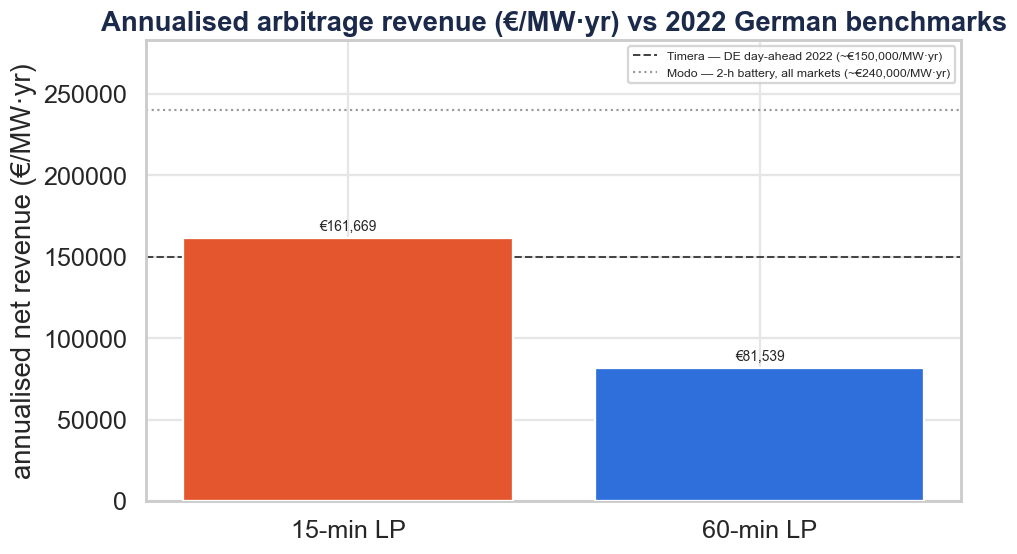

In [18]:
# Project the 6-month backtest onto the industry-standard unit: € per MW of power, per year.
# Battery revenue is quoted in €/MW·yr (revenue / power rating, annualised) — see the sanity-check below.

# --- Published 2022 German benchmarks (€/MW·yr) ---
BENCH_TIMERA_DA_2022 = 150_000   # Germany day-ahead arbitrage, realised 2022 (Timera Energy)
BENCH_MODO_ALLMKT    = 240_000   # 2-h battery, all markets (DA + intraday + FCR + aFRR) near-term (Modo Energy)

# --- Annualise the 6-month LP result. factor=2 (6 -> 12 months); exact day-count ~x2.02 is immaterial. ---
factor = 2.0
proj = pd.Series({
    "15-min LP": KPI["rev_15_lp"] / SPEC.power_mw * factor,
    "60-min LP": KPI["rev_60_lp"] / SPEC.power_mw * factor,
})
KPI["rev_15_lp_per_mw_yr"] = float(proj["15-min LP"])
KPI["rev_60_lp_per_mw_yr"] = float(proj["60-min LP"])
print(proj.round(0).to_string())
print(f"\n15-min LP projection: {proj['15-min LP']:,.0f} EUR/MW.yr (day-ahead only, perfect foresight)")

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(proj.index, proj.values, color=[plotting.PALETTE[1], plotting.PALETTE[0]], zorder=3)
ax.bar_label(bars, labels=[f"€{v:,.0f}" for v in proj.values], padding=3, fontsize=9)

# Published benchmarks as reference lines: like-for-like (Timera, day-ahead) and the full stack (Modo).
ax.axhline(BENCH_TIMERA_DA_2022, color="#444444", ls="--", lw=1.3, zorder=2,
           label=f"Timera — DE day-ahead 2022 (~€{BENCH_TIMERA_DA_2022:,.0f}/MW·yr)")
ax.axhline(BENCH_MODO_ALLMKT, color="#999999", ls=":", lw=1.4, zorder=2,
           label=f"Modo — 2-h battery, all markets (~€{BENCH_MODO_ALLMKT:,.0f}/MW·yr)")

ax.set(title="Annualised arbitrage revenue (€/MW·yr) vs 2022 German benchmarks",
       ylabel="annualised net revenue (€/MW·yr)", xlabel="")
ax.set_ylim(0, BENCH_MODO_ALLMKT * 1.18)
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
FIGS["revenue_projection"] = plotting.save_fig(fig, "06c_revenue_projection")
plt.show()

## 📏 Industry sanity-check — does the number make sense?

A model result is only worth trusting once it survives a reality check against the market. Our asset
is 1 MW, so the six-month LP total above already *is* a per-MW figure; annualising it to €/MW·yr:

$$\underbrace{80{,}835}_{\text{6 months, per MW}} \;\times\; 2 \;=\; 161{,}670\ \text{EUR/MW}\cdot\text{yr} \;\approx\; \mathbf{160\,\text{k EUR/MW}\cdot\text{yr}}.$$

**Does ≈ €160k/MW·yr fit the real 2022 market? Yes — against the right benchmark:**

- **Like-for-like (day-ahead only).** Timera Energy puts realised German day-ahead arbitrage at
  **≈ €150k/MW·yr in 2022** (easing to ~€100k in 2023 as the crisis passed). That is the *same single
  stream* we model, so our perfect-foresight **€160k** should sit **just above** it — and does, exactly
  as a ceiling should.
- **All-markets stack.** Modo Energy's **≈ €240k/MW·yr** spans day-ahead **+** intraday + FCR + aFRR
  together. We sit **well below** it — and that gap is real revenue from the markets this model leaves out.

So the number is **plausible and correctly scaled**, and it points to clear upside beyond the single
stream modelled here.

**Two assumptions it rests on** *(data is limited, so I keep them explicit):*

- **× 2 annualisation.** H1-2022 is doubled to a full year (the exact 365 / 181 ≈ 2.02 is immaterial).
  2022 was exceptionally volatile, so read this as an **order-of-magnitude** figure, not a normal-year forecast.
- **Perfect foresight ⇒ a ceiling.** The LP sees realised prices, so a real forecast-driven strategy
  captures less — a rough rule of thumb is **~50–80 %**.

## ✅ Recommendation

**My recommendation: trade the 15-minute contract**, and pair it with an **optimisation-based
dispatch** (like the LP) rather than a simple rule. On this data that combination would have captured
**~2×** the arbitrage of the 60-minute contract:

- **LP optimum:** **€80.8k vs €40.8k** over six months (1 MW / 2 MWh) — **≈ 2.0×**.
- **Simple 1-cycle/day rule:** **€38.9k vs €23.8k**.
- The driver is structural — **identical hourly averages**, but the 15-min market exposes an average
  **~€37/MWh of within-hour spread** and **wider daily spreads (€318 vs €152/MWh)**.

The size of the **LP − greedy gap** suggests real upside in *optimisation itself*, not just in the
choice of contract.

**Practical caveats I'd flag to a trading desk:**

- **Perfect foresight.** The numbers assume we know prices exactly in advance, which we never do — so
  treat them as a **best-case ceiling**; a real forecast-driven strategy captures less (a rough rule of
  thumb is ~50–80 %).
- **Liquidity.** The 15-minute order books are **thinner** than the hourly, so the full theoretical
  spread may not always be realisable in size — worth checking against traded volumes.
- **Battery life vs revenue.** A battery wears out with use (*degradation*). Cycling it **twice a day**
  earns more now but shortens its life (~16 yr vs ~20+ at once a day) and costs ~**€7/MWh** of wear.
  Over a long contract, owners also **add modules later** (*augmentation*) to keep capacity. So the best
  cycling rate **balances today's revenue against battery life and future top-up cost** — a multi-year
  question beyond this 6-month data.
- **Scope.** Day-ahead only — fees, grid charges and the intraday/balancing markets are excluded
  (see Limitations below).

## ⚠️ Limitations & next steps

Deliberate simplifications (kept honest for a pragmatic, ~4-hour scope):

- **Perfect foresight** — revenue is an upper bound; a forecast-driven dispatch captures less.
- **Each day is optimised on its own, starting from the 10% SoC floor** — I don't carry charge across
  midnight, so the model skips overnight arbitrage (buy late at night, sell into the next morning's
  peak). That's a small, conservative simplification: day-ahead value sits in the within-day spread,
  and the overnight trade would compete for the same 2-cycle/day budget. *(On normal days the battery
  empties to the floor by itself, so the reset has no effect; the only quirk is rare days ending in
  negative prices, where it is paid to charge and the leftover energy is dropped — negligible.)*
- **Greedy** is a deliberately naive baseline (it under-uses the second cycle) — hence the large LP gap.
- **Day-ahead only** — no intraday-continuous, balancing, FCR or aFRR revenue (these *add* to the
  stack); no **fees / grid charges**; **15-min liquidity** not modelled.
- **6 months** of one unusually volatile year (2022).
- **Battery capex, the degradation trajectory and augmentation** are not fully costed.

**Data I'd add next** (rather than now): more **price history** (several years / bidding zones) and
**intraday + ancillary-service** prices — to move from a single-stream upper bound to a realistic,
multi-market revenue estimate.

---
## References

- **Timera Energy** — [BESS arbitrage revenue ranked by country & duration](https://timera-energy.com/blog/bess-arbitrage-revenue-ranked-by-country-duration/) — day-ahead only; Germany ~€150k/MW·yr in 2022 (benchmark for §1.9).
- **Modo Energy** — [Top-bottom spread revenue benchmark](https://modoenergy.com/research/top-bottom-spread-revenue-benchmark-battery-energy-storage-sytems-gb-europe-spain-germany-solar-2025) (all-markets BESS revenue ~€240k/MW·yr) · [Battery degradation & cycling](https://modoenergy.com/research/battery-energy-storage-degradation-cycling-warranty).


# Appendix

## A · Worked micro-example — why LP optimisation beats the simple Greedy Algorihm?

The headline of Task 1 is that an **optimiser (the LP) earns far more than a simple rule**. One tiny day
shows *why*, with numbers small enough to check by hand: **8 hourly prices**, a **1 MWh** battery (no
losses, no wear, so the arithmetic is exact), allowed **2 charge→discharge cycles** in the day.

**The simple "greedy" rule is *time-blind*.** It ranks the whole day by price and plans to **charge in
the cheapest hours and sell in the dearest** — here the **2 cheapest** and the **2 dearest** (two cycles'
worth of energy fills and empties the battery twice). It decides purely by *price rank* and ignores the
**order in which the hours occur**. The figure shows that split: **left** in time order, **right** sorted
by price — the order the greedy actually thinks in.

*(Why exactly 2 hours each side? The battery may move 2 MWh over the day — its "budget" — and each hour
moves 1 MWh, so the budget buys 2 charge-hours and 2 sell-hours. On the real data the same budget works
out to about **13 of the 96** quarter-hours, or **3–4 of the 24** hourly slots.)*

budget = 2 x 1.0 = 2.0 MWh ; energy/interval = 1.00 MWh ; k = budget/(energy/interval) = 2


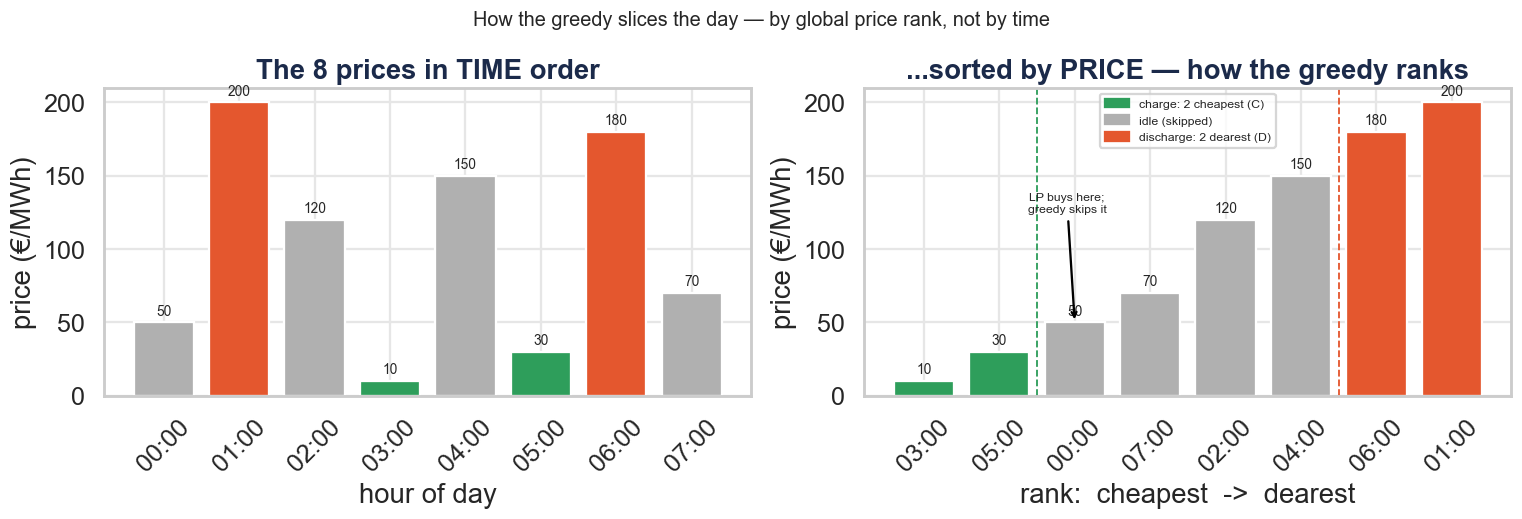

In [30]:
# The toy battery + prices (reused by the dispatch cell below).
toy_spec = BatterySpec(power_mw=1.0, capacity_mwh=1.0, round_trip_eff=1.0,
                       soc_min_frac=0.0, soc_max_frac=1.0, degradation_cost_eur_per_mwh=0.0)
toy_prices = pd.Series([50, 200, 120, 10, 150, 30, 180, 70],
                       index=pd.date_range("2022-01-01", periods=8, freq="h"), name="price")

# k is NOT set directly: it is the daily energy budget counted in intervals (see greedy_backtest).
dt = 1.0
budget = 2.0 * toy_spec.usable_capacity_mwh                  # N_cyc * E_use   (MWh, battery-side)
per_interval = toy_spec.eta_one_way * toy_spec.power_mw * dt  # eta * g_max     (MWh per interval)
k = int(round(budget / per_interval))
print(f"budget = 2 x {toy_spec.usable_capacity_mwh:.1f} = {budget:.1f} MWh ; "
      f"energy/interval = {per_interval:.2f} MWh ; k = budget/(energy/interval) = {k}")

# Partition the day by GLOBAL price rank: k cheapest -> charge, k dearest -> discharge, rest -> idle.
prices = toy_prices.to_numpy()
hours = [f"{h:02d}:00" for h in range(8)]
order = np.argsort(prices)                       # cheapest -> dearest
charge_i, discharge_i = set(order[:k]), set(order[-k:])
def colr(i):
    """Bar colour by role: green = charge, red = discharge, grey = idle."""
    if i in charge_i:
        return "#2e9e5b"
    if i in discharge_i:
        return "#e4572e"
    return "#b0b0b0"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.8))
ax1.bar(range(8), prices, color=[colr(i) for i in range(8)])
ax1.set(title="The 8 prices in TIME order", ylabel="price (€/MWh)", xlabel="hour of day")
ax1.set_xticks(range(8)); ax1.set_xticklabels(hours, rotation=45)
for i, v in enumerate(prices):
    ax1.text(i, v + 5, f"{v}", ha="center", fontsize=9)

ax2.bar(range(8), prices[order], color=[colr(i) for i in order])
ax2.axvline(k - 0.5, color="#2e9e5b", ls="--", lw=1.2)
ax2.axvline(8 - k - 0.5, color="#e4572e", ls="--", lw=1.2)
ax2.set(title="...sorted by PRICE — how the greedy ranks", ylabel="price (€/MWh)",
        xlabel="rank:  cheapest  ->  dearest")
ax2.set_xticks(range(8)); ax2.set_xticklabels([hours[i] for i in order], rotation=45)
for j, i in enumerate(order):
    ax2.text(j, prices[i] + 5, f"{prices[i]}", ha="center", fontsize=9)
pos = list(order).index(0)                        # 00:00 (€50) = the LP's profitable buy
ax2.annotate("LP buys here;\ngreedy skips it", xy=(pos, prices[0]),
             xytext=(pos - 0.1, prices[0] + 75), ha="center", fontsize=8,
             arrowprops=dict(arrowstyle="->", color="black"))
ax2.legend(handles=[Patch(color="#2e9e5b", label=f"charge: {k} cheapest (C)"),
                    Patch(color="#b0b0b0", label="idle (skipped)"),
                    Patch(color="#e4572e", label=f"discharge: {k} dearest (D)")],
           fontsize=8, loc="upper center")
fig.suptitle("How the greedy slices the day — by global price rank, not by time", fontsize=13)
fig.tight_layout()
FIGS["toy_partition"] = plotting.save_fig(fig, "06f_toy_partition")
plt.show()

**A plan only counts if it is physically possible.** You cannot sell before you have charged, and you
cannot charge a battery that is already full. Replaying the toy day in time order knocks out half the
greedy's chosen moves:

| hour | greedy plans to… | does it happen? | why |
|---|---|---|---|
| 01:00 | sell (2nd dearest) | **no** | battery still empty — nothing to sell yet |
| 03:00 | charge (cheapest) | yes → full | ok |
| 05:00 | charge (2nd cheapest) | **no** | battery already full — nowhere to put it |
| 06:00 | sell (dearest) | yes → empty | ok |

So of the 2 charges and 2 sells it picked, **only one of each can actually run**: a single round-trip,
buy €10 → sell €180 = **€170**. The second cycle is wasted because its cheap and dear hours do not
**interleave** in time. It even **misses the best trade of the day** — the €50 hour at 00:00 was only the
*3rd*-cheapest, just outside the shortlist, so the battery is never charged in time for the **€200** peak
right after it.

The **LP does not rank** — it plans the whole day at once, so it fits **two** clean round-trips
(00:00→01:00 and 03:00→06:00) for **€320 vs the greedy's €170**.

       price  greedy buy  greedy sell  LP buy  LP sell
00:00     50         0.0          0.0     1.0      0.0
01:00    200         0.0          0.0     0.0      1.0
02:00    120         0.0          0.0     0.0      0.0
03:00     10         1.0          0.0     1.0      0.0
04:00    150         0.0          0.0     0.0      0.0
05:00     30         0.0          0.0     0.0      0.0
06:00    180         0.0          1.0     0.0      1.0
07:00     70         0.0          0.0     0.0      0.0

Greedy day revenue: EUR 170
LP     day revenue: EUR 320   (+EUR 150 vs greedy)


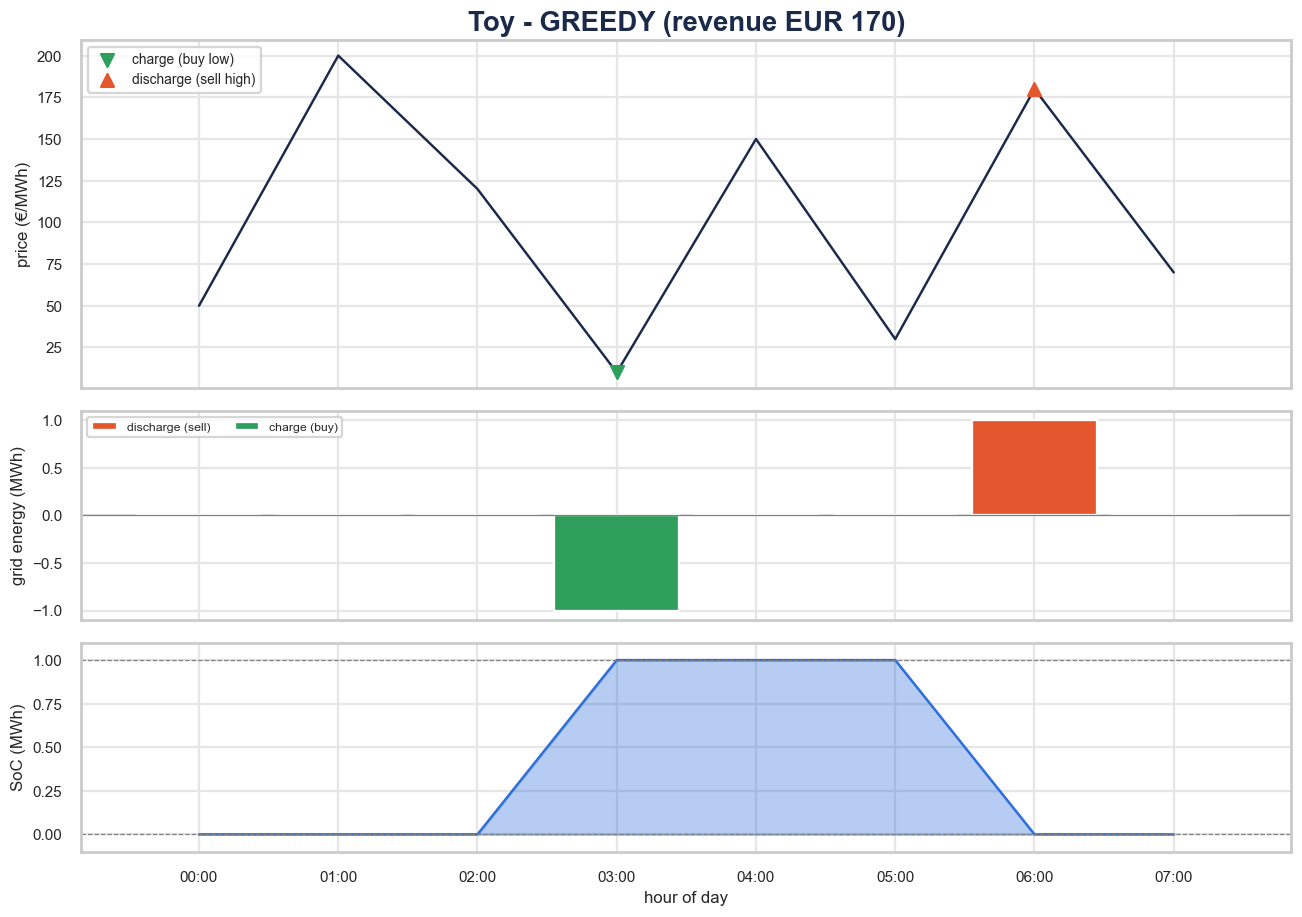

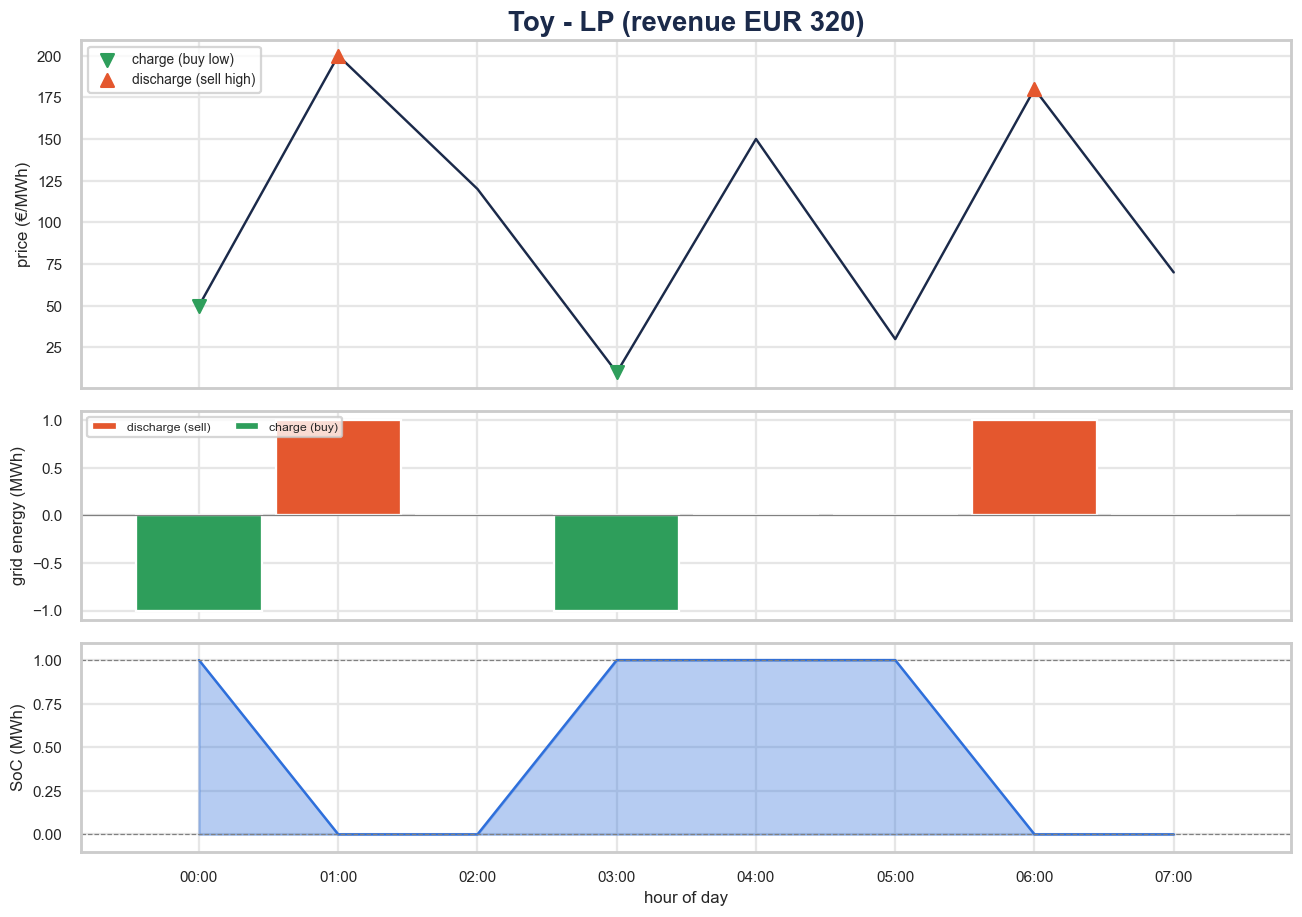

In [31]:
# Run BOTH strategies on the toy (the SAME functions used on the real data) and draw the dispatch.
g_toy = greedy_backtest(toy_prices, toy_spec, dt_hours=1.0, max_cycles_per_day=2.0)
lp_toy = lp_optimize(toy_prices, toy_spec, dt_hours=1.0, max_cycles_per_day=2.0, use_degradation=False)
gs, ls = g_toy["schedule"], lp_toy["schedule"]

# MWh bought / sold each hour by each strategy (with the price to hand).
table = pd.DataFrame({
    "price": toy_prices.values,
    "greedy buy": gs["charge_grid"].values, "greedy sell": gs["discharge_grid"].values,
    "LP buy": ls["charge_grid"].values, "LP sell": ls["discharge_grid"].values,
}, index=[f"{h:02d}:00" for h in range(8)]).round(2)
print(table.to_string())
print(f"\nGreedy day revenue: EUR {g_toy['total_revenue_eur']:.0f}")
print(f"LP     day revenue: EUR {lp_toy['total_revenue_eur']:.0f}   "
      f"(+EUR {lp_toy['total_revenue_eur'] - g_toy['total_revenue_eur']:.0f} vs greedy)")

# Toy figures: every hour on the x-axis (tick_hours=1) and full SoC range (soc_margin=0.1).
FIGS["toy_greedy"] = plot_dispatch(
    gs, toy_spec, f"Toy - GREEDY (revenue EUR {g_toy['total_revenue_eur']:.0f})",
    "06d_toy_greedy", tick_hours=1, soc_margin=0.1)
FIGS["toy_lp"] = plot_dispatch(
    ls, toy_spec, f"Toy - LP (revenue EUR {lp_toy['total_revenue_eur']:.0f})",
    "06e_toy_lp", tick_hours=1, soc_margin=0.1)

| | buys at | sells at | revenue |
|---|---|---|---|
| **Greedy** (ranks by price) | €10 | €180 | **€170** |
| **LP** (plans the whole day) | €50 + €10 | €200 + €180 | **€320** |

The greedy even buys **cheaper** (€10 vs €50) yet earns **less**: a low buy price only pays off if it can
be matched to a *later, higher* sale — which a time-blind ranking cannot guarantee. The same effect shows
up on the real 2022 data in §1.8, where the greedy idles through the early hours while the LP charges into
the overnight price spike.